In [1]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pandas_datareader.data import DataReader
from statsmodels.tsa.statespace.dynamic_factor import DynamicFactor
import datetime
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.vector_ar.vecm import coint_johansen
import statsmodels.api as sm
import arviz as az
import pytensor.tensor as pt
import pymc as pm
import pytensor

from pymc_extras.statespace.core.statespace import PyMCStateSpace
from pymc_extras.statespace.utils.constants import (
    ALL_STATE_AUX_DIM,
    ALL_STATE_DIM
)
from pymc_extras.statespace.models.DFM import BayesianDynamicFactor

# Introduction  

This notebook implements a **Dynamic Factor Model (DFM)** to construct a macroeconomic coincident index, capturing the common component of the *business cycle*. The implementation is inspired by the [Statsmodels example](https://www.statsmodels.org/dev/examples/notebooks/generated/statespace_dfm_coincident.html) and leverages the `pymc_extras.statespace` package for building the DFM.  


# Data  

We will use a dataset of four key macroeconomic variables from the [FRED database](https://fred.stlouisfed.org/):  

- **Industrial Production** (`IPMAN`)  
- **Real Aggregate Income** (excluding transfer payments, `W875RX1`)  
- **Manufacturing and Trade Sales** (`CMRMTSPL`)  
- **Employees on Non-Farm Payrolls** (`PAYEMS`)  

In [2]:
# Download the data
# Series: INDPRO, PAYEMS, MANEMP, and RRSFS
# Monthly data from 1959-01 to 2020-12
start = datetime.datetime(1979, 1, 1)
end = datetime.datetime(2014, 12, 31)

indprod = DataReader("IPMAN", "fred", start=start, end=end)
income = DataReader("W875RX1", "fred", start=start, end=end)
sales = DataReader("CMRMTSPL", "fred", start=start, end=end)
emp = DataReader("PAYEMS", "fred", start=start, end=end)

data = pd.concat((indprod, income, sales, emp), axis=1)
data.columns = ["indprod", "income", "sales", "emp"]
data.index.freq = data.index.inferred_freq

print(data.head())

            indprod  income       sales    emp
DATE                                          
1979-01-01  47.1722  5248.7  561382.192  88808
1979-02-01  47.3093  5278.5  558729.039  89055
1979-03-01  47.5389  5294.3  574897.892  89479
1979-04-01  46.7402  5242.7  559387.521  89417
1979-05-01  47.3949  5227.5  571771.305  89789


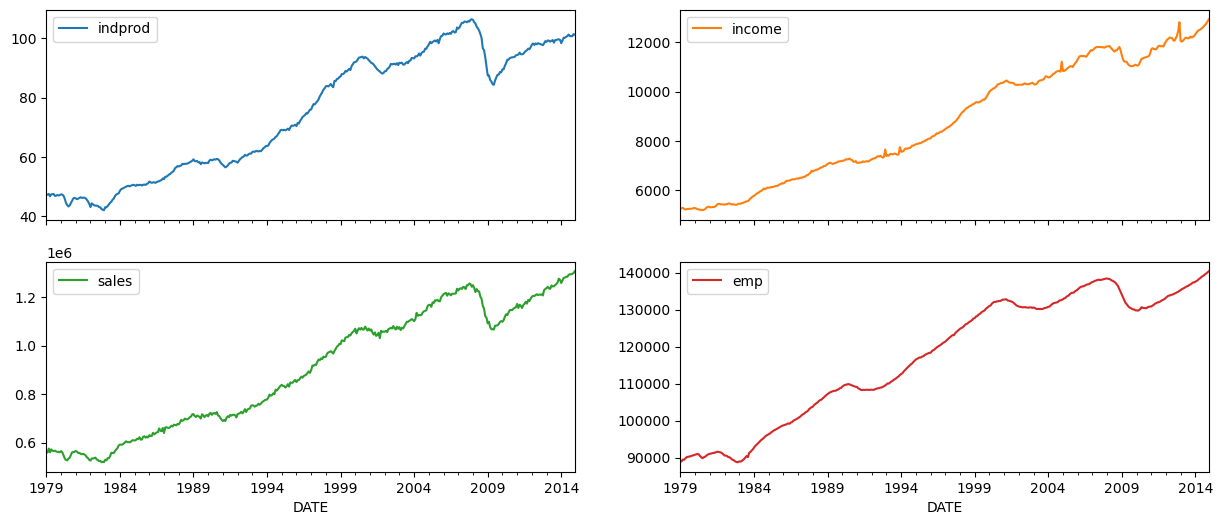

In [3]:
data.loc[:, "indprod":"emp"].plot(subplots=True, layout=(2, 2), figsize=(15, 6));

### Cointegration

In [4]:
def johansen_cointegration_test(df, det_order=-1, k_ar_diff=1):
    """
    Perform Johansen cointegration test
    det_order: Deterministic trend assumption (-1 to 3)
    k_ar_diff: Lag order for differencing (usually 1)
    """
    print("Johansen Cointegration Test Results")
    coint_test = coint_johansen(df.dropna(), det_order, k_ar_diff)

    trace_stat = coint_test.lr1
    crit_values = coint_test.cvt

    for i in range(len(trace_stat)):
        print(f"Rank {i}: Trace Statistic = {trace_stat[i]:.2f}, 90% CV = {crit_values[i, 0]:.2f}, 95% CV = {crit_values[i, 1]:.2f}, 99% CV = {crit_values[i, 2]:.2f}")
        if trace_stat[i] > crit_values[i, 1]:
            print("=> Reject H0: Cointegration rank >=", i)
        else:
            print("=> Fail to reject H0: Cointegration rank <", i)
        print()


In [5]:
coint_data = (data[['indprod', 'income', 'sales', 'emp']])
johansen_cointegration_test(coint_data)

Johansen Cointegration Test Results
Rank 0: Trace Statistic = 85.23, 90% CV = 37.03, 95% CV = 40.17, 99% CV = 46.57
=> Reject H0: Cointegration rank >= 0

Rank 1: Trace Statistic = 27.72, 90% CV = 21.78, 95% CV = 24.28, 99% CV = 29.51
=> Reject H0: Cointegration rank >= 1

Rank 2: Trace Statistic = 6.23, 90% CV = 10.47, 95% CV = 12.32, 99% CV = 16.36
=> Fail to reject H0: Cointegration rank < 2

Rank 3: Trace Statistic = 1.36, 90% CV = 2.98, 95% CV = 4.13, 99% CV = 6.94
=> Fail to reject H0: Cointegration rank < 3



The Johansen test indicates the presence of 2 cointegrating relationships among the 4 time series. This means there are 2 independent stationary linear combinations (cointegrating vectors). However, we will follow our reference, testing stationarity for each time series and eventually applying a tranformation.


### Stationarity

In [6]:
def adf_test(series, title=''):
    """
    Perform Augmented Dickey-Fuller test
    """
    print(f'ADF Test for {title}')
    result = adfuller(series.dropna(), autolag='AIC')
    labels = ['ADF Statistic', 'p-value', '# Observations']
    for value, label in zip(result[:4], labels):
        print(f"{label}: {value}")
    if result[1] <= 0.05:
        print("=> Stationary (reject H0)")
    else:
        print("=> Non-stationary (fail to reject H0)")
    print()


In [7]:

for col in ['indprod', 'income', 'sales', 'emp']:
    adf_test(data[col], title=col)
   

ADF Test for indprod
ADF Statistic: -0.6730347475672281
p-value: 0.85361106826554
# Observations: 12
=> Non-stationary (fail to reject H0)

ADF Test for income
ADF Statistic: 0.08298432353926344
p-value: 0.9648799685690177
# Observations: 9
=> Non-stationary (fail to reject H0)

ADF Test for sales
ADF Statistic: -0.2149222275829695
p-value: 0.9367193955682982
# Observations: 12
=> Non-stationary (fail to reject H0)

ADF Test for emp
ADF Statistic: -0.9032661691141215
p-value: 0.7868949183862886
# Observations: 3
=> Non-stationary (fail to reject H0)



The **Augmented Dickey-Fuller (ADF) test** indicates that our time series are not stationary.  
To address this, we should apply appropriate transformations to achieve stationarity before modeling.  


In [8]:
# Create log-differenced series
data["dln_indprod"] = (np.log(data.indprod)).diff() * 100
data["dln_income"] = (np.log(data.income)).diff() * 100
data["dln_sales"] = (np.log(data.sales)).diff() * 100
data["dln_emp"] = (np.log(data.emp)).diff() * 100

# De-mean and standardize
data["std_indprod"] = (data["dln_indprod"] - data["dln_indprod"].mean()) / data[
    "dln_indprod"
].std()
data["std_income"] = (data["dln_income"] - data["dln_income"].mean()) / data[
    "dln_income"
].std()
data["std_sales"] = (data["dln_sales"] - data["dln_sales"].mean()) / data["dln_sales"].std()
data["std_emp"] = (data["dln_emp"] - data["dln_emp"].mean()) / data["dln_emp"].std()

In [9]:
# Get the endogenous data
endog = data.loc["1979-02-01":, "std_indprod":"std_emp"]

In [10]:
for col in ["std_indprod","std_income", "std_sales", "std_emp"]:
    adf_test(endog[col], title=col)

ADF Test for std_indprod
ADF Statistic: -7.333717380953279
p-value: 1.1105668612347841e-10
# Observations: 2
=> Stationary (reject H0)

ADF Test for std_income
ADF Statistic: -4.455094080898936
p-value: 0.00023683228344774555
# Observations: 13
=> Stationary (reject H0)

ADF Test for std_sales
ADF Statistic: -8.82793508643558
p-value: 1.8022396062718537e-14
# Observations: 2
=> Stationary (reject H0)

ADF Test for std_emp
ADF Statistic: -4.1756318714355185
p-value: 0.0007243551568346677
# Observations: 2
=> Stationary (reject H0)



As noted in the reference notebook, following the findings of *Stock and Watson (1991)*, stationarity can be achieved by applying a **log transformation** to the series and then taking their **first differences**.  


In [11]:
print(endog.head())

            std_indprod  std_income  std_sales   std_emp
DATE                                                    
1979-02-01     0.144369    0.536870  -0.722874  0.897660
1979-03-01     0.392176    0.134841   2.867766  1.929842
1979-04-01    -2.391601   -1.787951  -3.163686 -0.918544
1979-05-01     1.550990   -0.751468   2.151995  1.616819
1979-06-01    -0.067774   -0.076092  -1.319191  1.300121


## Statsmodel


### Model specification

In this application, we consider a **dynamic factor model** with a single latent factor.  
The factor is assumed to follow an **AR(2)** process. Each observed series has its own error term, modeled as an **independent AR(2)** process. The innovations driving the factor and the errors are assumed to be mutually independent, so the covariance structure is diagonal.

Formally, the model is:

$$
y_{i,t} = \lambda_i f_t + u_{i,t}
$$

$$
u_{i,t} = c_{i,1} u_{i,t-1} + c_{i,2} u_{i,t-2} + \varepsilon_{i,t}
$$

$$
f_t = a_1 f_{t-1} + a_2 f_{t-2} + \eta_t
$$

$$
\varepsilon_{i,t} \sim \mathcal{N}(0, \sigma_i^2), \qquad 
\eta_t \sim \mathcal{N}(0, I)
$$

where \(i\) is one of: `[indprod, income, sales, emp]`.


---

This setup can be represented using the `DynamicFactor` class from **statsmodels** with the following configuration:

- `k_factors = 1` — one unobserved dynamic factor  
- `factor_order = 2` — the latent factor follows an AR(2)  
- `error_order = 2` — idiosyncratic errors are AR(2)  
- `error_var = False` — errors are treated separately rather than as a VAR (default setting)  
- `error_cov_type = 'diagonal'` — innovations are uncorrelated across series (also the default)  

---

After specifying the model, the unknown parameters are estimated by **maximum likelihood**, using the `.fit()` method.



In [12]:
# Fit the Dynamic Factor Model
mod = DynamicFactor(endog, k_factors=1, factor_order=2, error_order=2, error_var=False, error_cov_type='diagonal')
initial_res = mod.fit(method="powell", disp=False)
res = mod.fit(disp=False)
print(res.summary())

                                             Statespace Model Results                                            
Dep. Variable:     ['std_indprod', 'std_income', 'std_sales', 'std_emp']   No. Observations:                  431
Model:                                 DynamicFactor(factors=1, order=2)   Log Likelihood               -2050.782
                                                          + AR(2) errors   AIC                           4137.564
Date:                                                   Sun, 17 Aug 2025   BIC                           4210.754
Time:                                                           10:57:17   HQIC                          4166.462
Sample:                                                       02-01-1979                                         
                                                            - 12-01-2014                                         
Covariance Type:                                                     opg                

/opt/anaconda3/envs/pymc_extras/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


We print the model matrices to allow for an easy comparison with the **PyMC Dynamic Factor Model (DFM)** implementation.  


In [13]:
# Access the state-space representation
ssm = res.model.ssm

# Print the main state-space matrices
print("\nDesign matrix (Z):")
print(ssm['design'])

print("\nTransition matrix (T):")
print(ssm['transition'])

print("\nSelection matrix (R):")
print(ssm['selection'])

print("\nState covariance matrix (Q):")
print(ssm['state_cov'])

print("\nObservation intercept (d):")
print(ssm['obs_intercept'])

print("\nState intercept (c):")
print(ssm['state_intercept'])

print("\nObservation covariance matrix (H):")
print(ssm['obs_cov'])


Design matrix (Z):
[[-0.69536284  0.          1.          0.          0.          0.
   0.          0.          0.          0.        ]
 [-0.25042682  0.          0.          1.          0.          0.
   0.          0.          0.          0.        ]
 [-0.4372834   0.          0.          0.          1.          0.
   0.          0.          0.          0.        ]
 [-0.42548075  0.          0.          0.          0.          1.
   0.          0.          0.          0.        ]]

Transition matrix (T):
[[ 0.30237198  0.36710486  0.          0.          0.          0.
   0.          0.          0.          0.        ]
 [ 1.          0.          0.          0.          0.          0.
   0.          0.          0.          0.        ]
 [ 0.          0.         -0.22851633  0.          0.          0.
  -0.17556443  0.          0.          0.        ]
 [ 0.          0.          0.         -0.19801159  0.          0.
   0.         -0.10249204  0.          0.        ]
 [ 0.          0.  

The **unobserved factor** is plotted below together with the **NBER recession indicators** for the U.S. economy.  
The results suggest that the factor successfully captures key features of business cycle activity.  


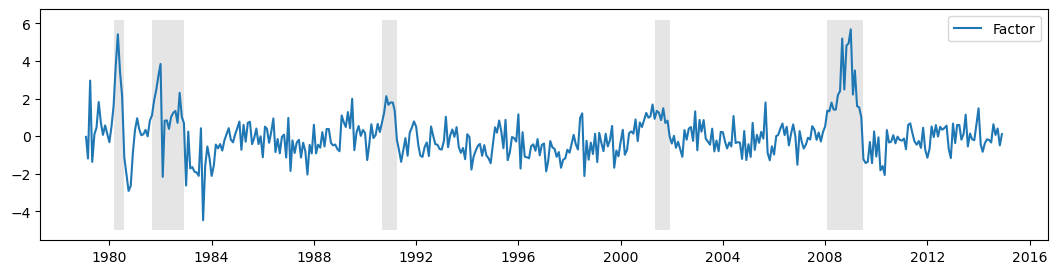

In [25]:
fig, ax = plt.subplots(figsize=(13, 3))

# Plot the factor
dates = endog.index._mpl_repr()
ax.plot(dates, res.factors.filtered[0], label="Factor")
ax.legend()

# Retrieve and also plot the NBER recession indicators
rec = DataReader("USREC", "fred", start=start, end=end)
ylim = ax.get_ylim()
ax.fill_between(
    dates[:-3], ylim[0], ylim[1], rec.values[:-4, 0], facecolor="k", alpha=0.1
);

A simple way to interpret the estimated factor is to **regress it on each observed variable** and record the \(R^2\) values.  
This shows which variables the factor explains well and which it does not.  

In our model with **one factor and four variables**, the factor explains most of the variation in **industrial production**, a large portion in **employment** and **sales**, and less in **income**. 

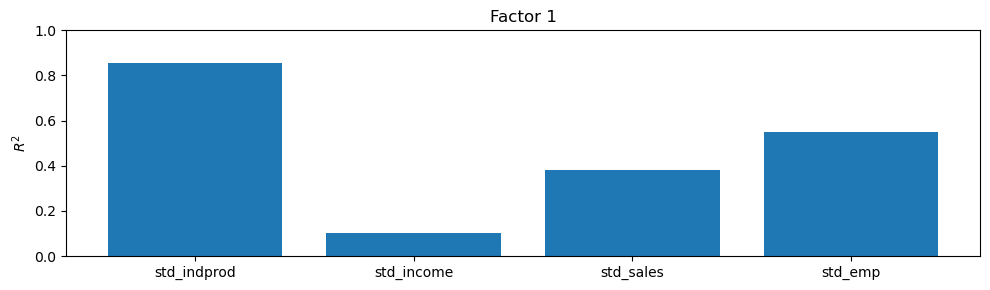

In [35]:
fig = res.plot_coefficients_of_determination(figsize=(10, 3))
ax = fig.axes[0]  

var_names = res.model.endog_names

ax.set_xticks(range(len(var_names)))
ax.set_xticklabels(var_names, rotation=0, ha='center')

plt.tight_layout()
plt.show()

As already said, the goal of this model is to construct an **interpretable coincident index** that reflects the current state of the macroeconomy.  
The index is built by reconstructing the mean of the (differenced) factor and can be compared to the **US coincident index published by the Federal Reserve Bank of Philadelphia** (USPHCI on FRED).  
For details on the methodology, see *Kim and Nelson (1999)* or *Stock and Watson (1991)*.
Below we plot this reference index (USPHCI)


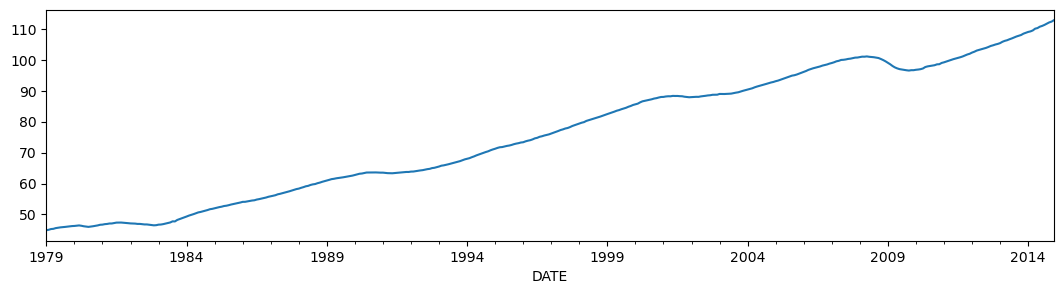

In [36]:
usphci = DataReader("USPHCI", "fred", start=start, end=end)["USPHCI"]
usphci.plot(figsize=(13, 3));

In [37]:
dusphci = usphci.diff()[1:].values

def compute_coincident_index(mod, res):
    # Estimate W(1)
    spec = res.specification
    design = mod.ssm["design"]
    transition = mod.ssm["transition"]
    ss_kalman_gain = res.filter_results.kalman_gain[:, :, -1]

    k_states = ss_kalman_gain.shape[0]

    W1 = np.linalg.inv(
        np.eye(k_states)
        - np.dot(np.eye(k_states) - np.dot(ss_kalman_gain, design), transition)
    ).dot(ss_kalman_gain)[0]

    # Compute the factor mean vector
    factor_mean = np.dot(W1, data.loc[start:, "dln_indprod":"dln_emp"].mean())

    # Normalize the factors
    factor = res.factors.filtered[0].copy()

    factor *= np.std(usphci.diff()[1:]) / np.std(factor)

    # Compute the coincident index
    coincident_index = np.zeros(mod.nobs + 1)
    # The initial value is arbitrary; here it is set to
    # facilitate comparison
    coincident_index[0] = usphci.iloc[0] * factor_mean / dusphci.mean()
    for t in range(0, mod.nobs):
        coincident_index[t + 1] = coincident_index[t] + factor[t] + factor_mean

    # Attach dates
    coincident_index = pd.Series(coincident_index, index=data.index).iloc[1:]

    # Normalize to use the same base year as USPHCI
    coincident_index *= usphci.loc["1992-07-01"] / coincident_index.loc["1992-07-01"]

    return coincident_index, factor

Below we plot the calculated coincident index along with the US recessions and the comparison coincident index USPHCI.

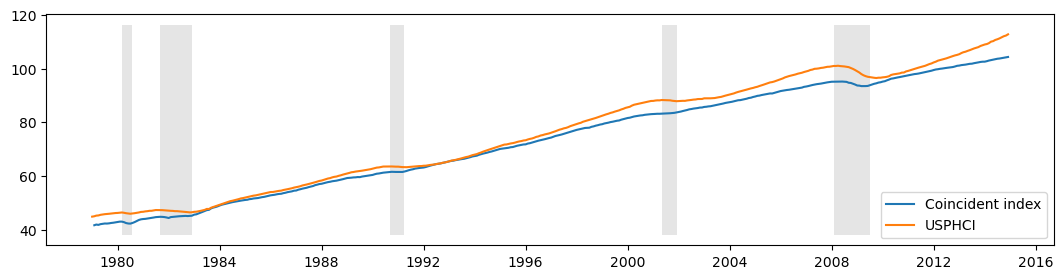

In [38]:
fig, ax = plt.subplots(figsize=(13, 3))

# Compute the index
coincident_index_res, factor_res = compute_coincident_index(mod, res)

# Plot the factor
dates = endog.index._mpl_repr()
ax.plot(dates, coincident_index_res, label="Coincident index")
ax.plot(usphci.index._mpl_repr(), usphci, label="USPHCI")
ax.legend(loc="lower right")

# Retrieve and also plot the NBER recession indicators
ylim = ax.get_ylim()
ax.fill_between(
    dates[:-3], ylim[0], ylim[1], rec.values[:-4, 0], facecolor="k", alpha=0.1
);

## PyMC

We now aim to **replicate the results obtained with Statsmodels** in a **Bayesian framework** using the `BayesianDynamicFactor` model from the `pymc-extras` package.

In [39]:
matrix_names = [
    "initial_state",
    "initial_state_cov",
    "state_intercept",
    "obs_intercept",
    "transition",
    "design",
    "selection",
    "obs_cov",
    "state_cov",
]


def print_model_ssm(mod, how="eval"):
    nice_heading = f'{"name":<20}{"__repr__":<50}{"shape":<10}{"value":<20}'
    print(nice_heading)
    print("=" * len(nice_heading))
    if how == "eval":
        matrices = [x.eval() for x in mod._unpack_statespace_with_placeholders()]
    elif how == "draw":
        matrices = pm.draw(mod.unpack_statespace())

    for name, value in zip(matrix_names, matrices):
        repr_ = str(mod.ssm[name])
        shape = str(mod.ssm[name].type.shape)
        value = str(value).replace("\n ", "\n" + " " * 81)
        print(f"{name:<20}{repr_:<50}{shape:<10}{value:<20}")
        print("-" * len(nice_heading))

We define the **same model** in the Bayesian framework to ensure comparability with the Statsmodels results.  
The PyMC implementation uses the `BayesianDynamicFactor` class from `pymc_extras.statespace`.  
For details on its parameters, state-space formulation, and handling of exogenous variables, see the [official documentation](https://github.com/pymc-devs/pymc-extras/blob/main/pymc_extras/statespace/models/DFM.py#L1).  

This implementation allows greater flexibility than Statsmodels, particularly in integrating exogenous variables directly into the state-space representation.



In [21]:
# Initialize the model
dfm = BayesianDynamicFactor(
    k_endog=4,
    k_factors=1,
    factor_order=2,
    error_order=2,
    error_var=False,
    error_cov_type="diagonal",
    measurement_error=False,
    verbose=True,
)

                                     Model Requirements                                     
                                                                                            
  Variable          Shape      Constraints                                      Dimensions  
 ────────────────────────────────────────────────────────────────────────────────────────── 
  x0                (10,)                                                       ('state',)  
  P0                (10, 10)   Positive Semi-definite               ('state', 'state_aux')  
  factor_loadings   (4, 1)                                    ('observed_state', 'factor')  
  factor_ar         (1, 2)                                            ('factor', 'lag_ar')  
  error_ar          (4, 2)                              ('observed_state', 'error_lag_ar')  
  error_sigma       (4,)       Positive                                ('observed_state',)  
                                                                                            
  These parameters should be assigned priors inside a PyMC model block before calling the   
                               build_statespace_graph method.                               

In [40]:
params = res.params.to_dict()

with pm.Model() as pymc_mod:

    # Initial state
    x0 = pm.Deterministic("x0", pt.zeros(10))
    P0 = pm.Deterministic("P0", pt.eye(10))

    # Factor loadings vector
    lambda_vals = [
        params['loading.f1.std_indprod'],
        params['loading.f1.std_income'],
        params['loading.f1.std_sales'],
        params['loading.f1.std_emp']
    ]
    factor_loadings = pm.Normal("factor_loadings", mu=pt.constant(lambda_vals).reshape((4,1)), sigma=0.2, shape=(4,1))

    # AR(2) coefficients for factor f_t
    ar_vals = [
        params['L1.f1.f1'],
        params['L2.f1.f1']
    ]
    factor_ar = pm.Normal("factor_ar", mu=pt.constant(ar_vals), sigma=0.1, shape=(1,2))

    # AR(2) coefficients for idiosyncratic components as matrix error_ar_mu: shape (4, 2)
    error_ar_mu = [
        [params['L1.e(std_indprod).e(std_indprod)'], params['L2.e(std_indprod).e(std_indprod)']],
        [params['L1.e(std_income).e(std_income)'], params['L2.e(std_income).e(std_income)']],
        [params['L1.e(std_sales).e(std_sales)'], params['L2.e(std_sales).e(std_sales)']],
        [params['L1.e(std_emp).e(std_emp)'], params['L2.e(std_emp).e(std_emp)']]
    ]
    error_ar = pm.Normal("error_ar", mu=pt.constant(error_ar_mu), sigma=0.1, shape=(4, 2))

    # Standard deviations for idiosyncratic shocks
    error_sigma_vals = [
        params['sigma2.std_indprod'],
        params['sigma2.std_income'],
        params['sigma2.std_sales'],
        params['sigma2.std_emp']
    ]
    error_sigma = pm.HalfNormal("error_sigma", sigma=pt.constant(error_sigma_vals), shape=(4))

    # Build symbolic graph
    dfm.build_statespace_graph(data=endog, mode="JAX")

In [23]:
print_model_ssm(dfm, "draw")

name                __repr__                                          shape     value               
initial_state       initial_state                                     (10,)     [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
----------------------------------------------------------------------------------------------------
initial_state_cov   initial_state_cov                                 (10, 10)  [[1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
                                                                                 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
                                                                                 [0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
                                                                                 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
                                                                                 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
                                                                                 [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
        

In [ ]:
with pymc_mod:
    idata_dfm_py= pm.sample(
    draws=500,
    chains=1,
    nuts_sampler="nutpie",
    nuts_sampler_kwargs={"backend": "jax", "gradient_backend": "jax"},
)

Progress,Draws,Divergences,Step Size,Gradients/Draw
,187,0,0.49,7


/opt/anaconda3/envs/pymc_extras/lib/python3.11/site-packages/arviz/data/base.py:272: UserWarning: More chains (1) than draws (0). Passed array should have shape (chains, draws, *shape)
  warnings.warn(


In [ ]:
# idata_dfm_py.to_netcdf("Results/NutpieNoPrior3.nc")

'Results/NutpieNoPrior.nc'

In [45]:
idata_dfm_py = az.from_netcdf("Results/NutpieNoPrior3.nc")

With the usual **energy plot**, we examine the behavior of the sampling procedure.  
It shows the **efficiency and convergence** of the MCMC chains, indicating that the sampler was able to explore the posterior distribution effectively.



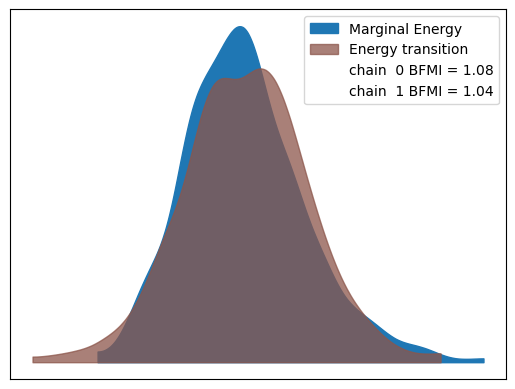

In [46]:
az.plot_energy(idata_dfm_py);

In [47]:
var_names_list_dfm_py = [name for name in dfm.param_names if name not in {"x0", "P0"}]

In [48]:
az.summary(idata_dfm_py, var_names=var_names_list_dfm_py)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
"factor_loadings[0, 0]",-0.001,0.674,-0.740,0.730,0.472,0.001,3.0,225.0,1.83
"factor_loadings[1, 0]",-0.000,0.243,-0.296,0.283,0.169,0.001,3.0,92.0,1.83
"factor_loadings[2, 0]",0.000,0.427,-0.474,0.473,0.299,0.001,3.0,96.0,1.83
"factor_loadings[3, 0]",0.002,0.401,-0.458,0.450,0.281,0.001,3.0,63.0,1.83
"factor_ar[0, 0]",0.315,0.061,0.214,0.436,0.002,0.002,794.0,772.0,1.00
"factor_ar[0, 1]",0.353,0.060,0.247,0.466,0.002,0.002,1078.0,829.0,1.00
"error_ar[0, 0]",-0.195,0.090,-0.371,-0.031,0.003,0.002,1291.0,797.0,1.00
"error_ar[0, 1]",-0.134,0.078,-0.275,0.014,0.003,0.002,938.0,672.0,1.01
"error_ar[1, 0]",-0.188,0.046,-0.270,-0.099,0.001,0.002,1645.0,662.0,1.00
"error_ar[1, 1]",-0.091,0.044,-0.173,-0.010,0.001,0.001,2092.0,774.0,1.00


The **trace plot** visualizes the sampled values of each parameter over the MCMC iterations, showing a good sampling procedure for our state space model.

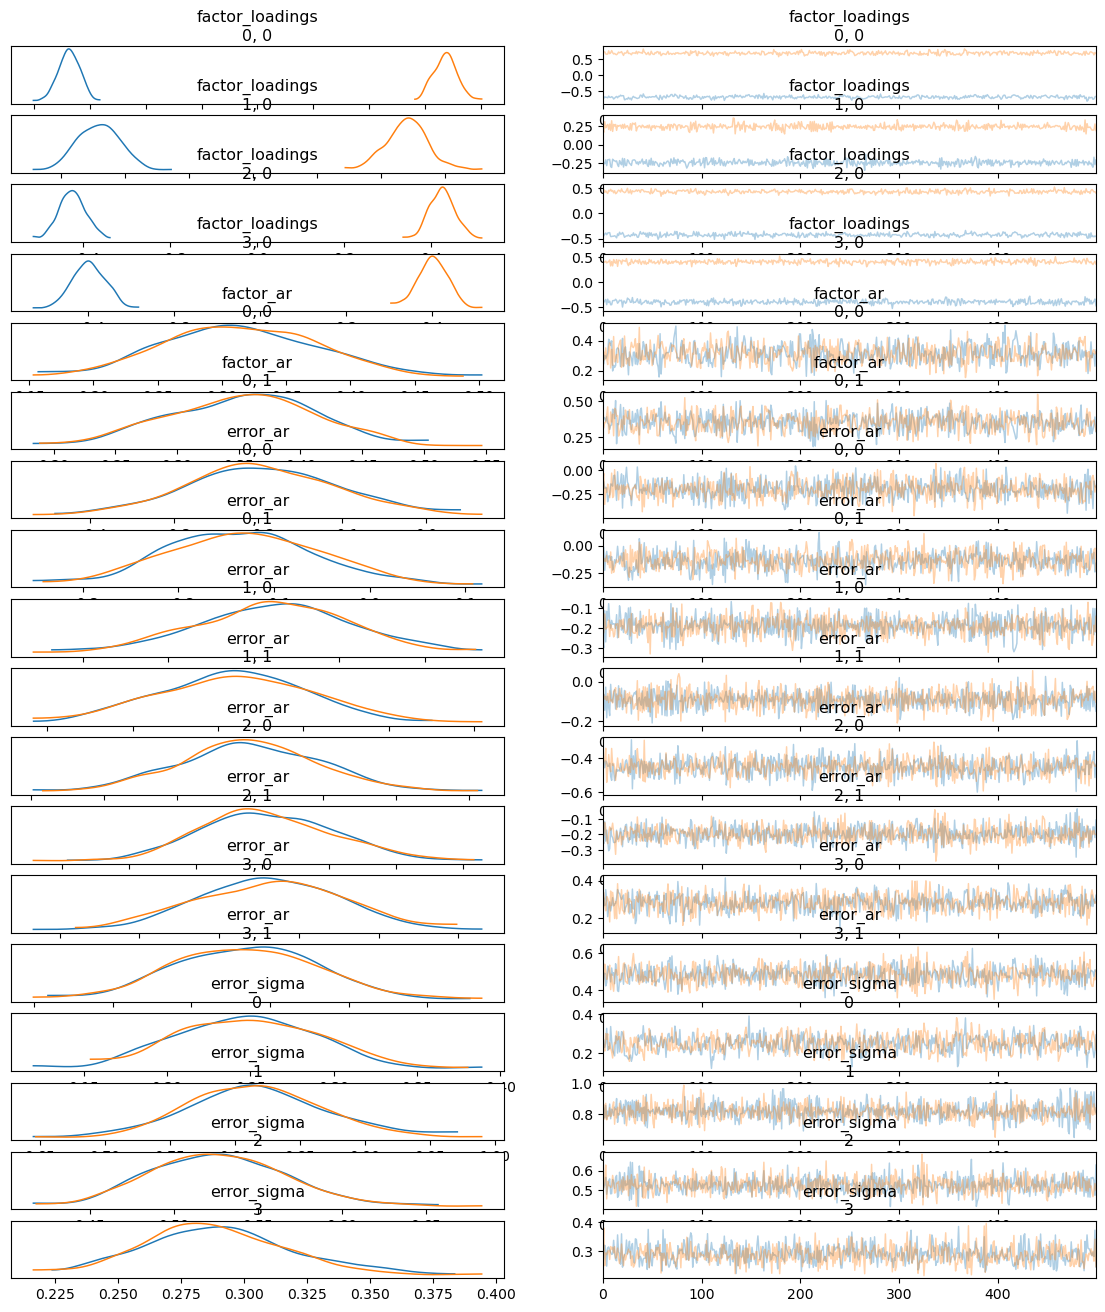

In [49]:
az.plot_trace(
    idata_dfm_py,
    var_names=var_names_list_dfm_py,
    figsize=(14, 16),
    compact=False
);

We compare the **posterior distributions** of the model parameters with the reference values estimated by Statsmodels.  
All reference estimates **fall within the Bayesian credible intervals**, indicating good agreement between the two approaches.


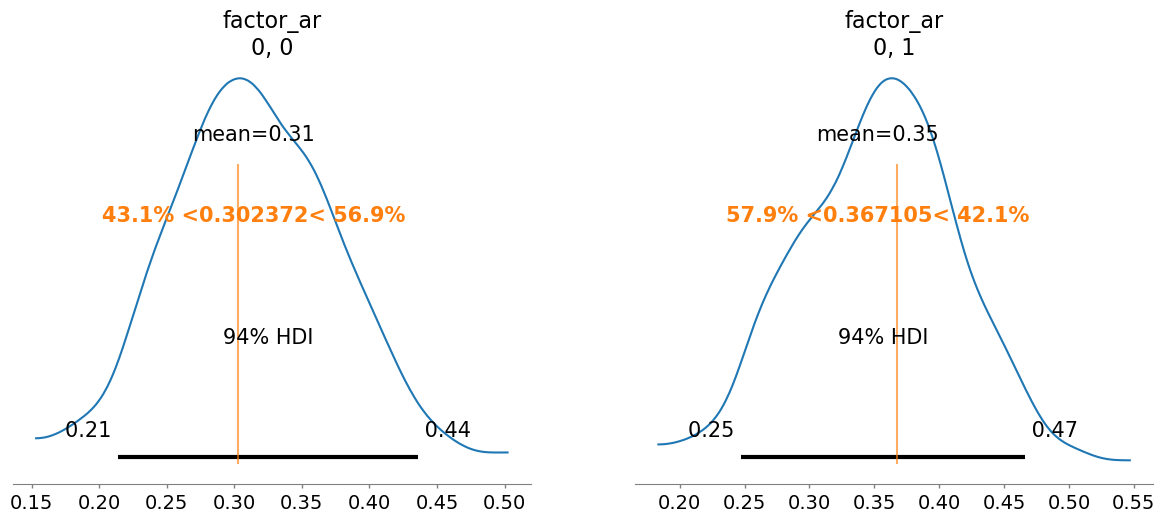

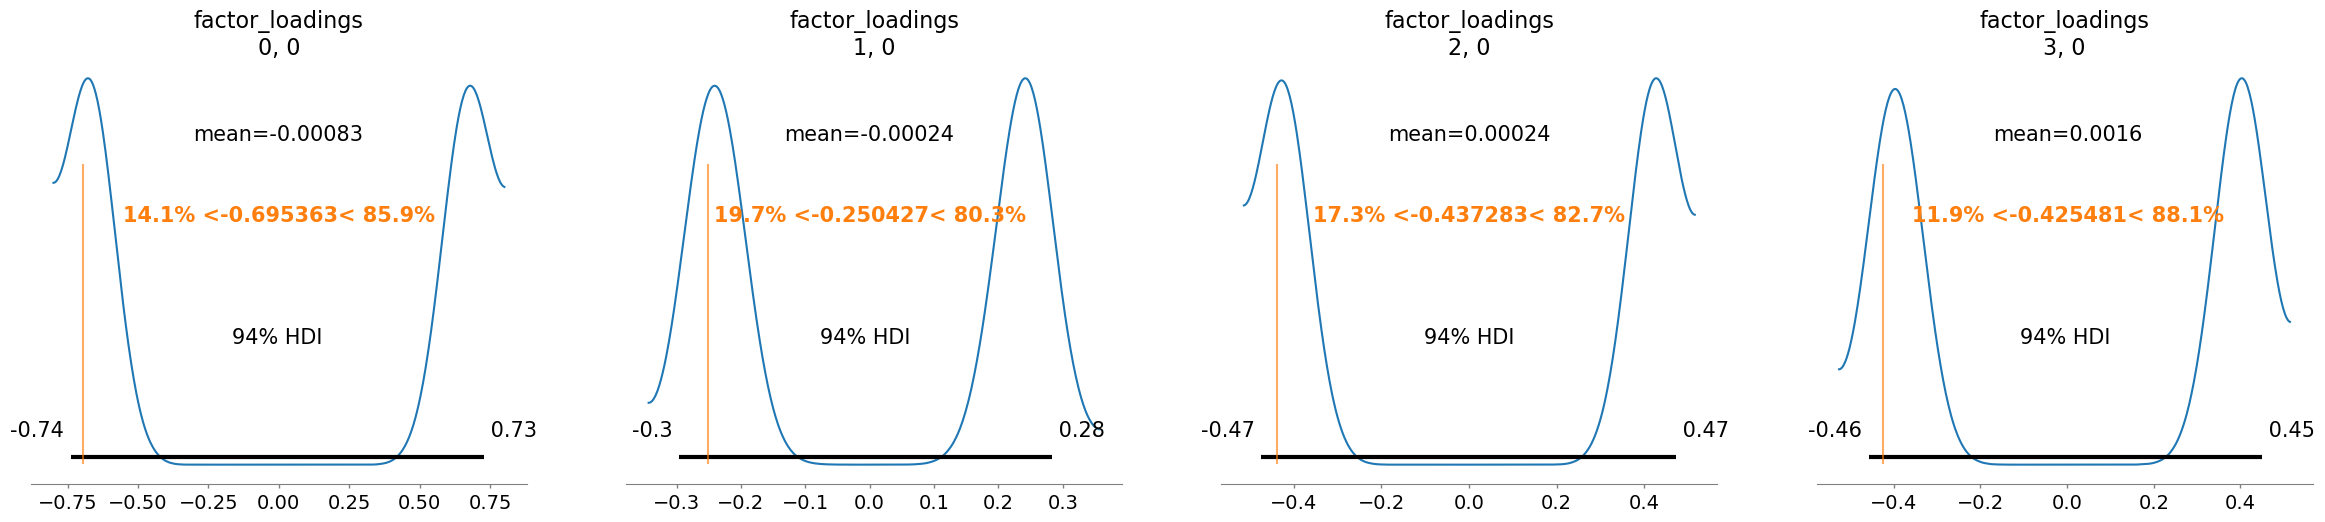

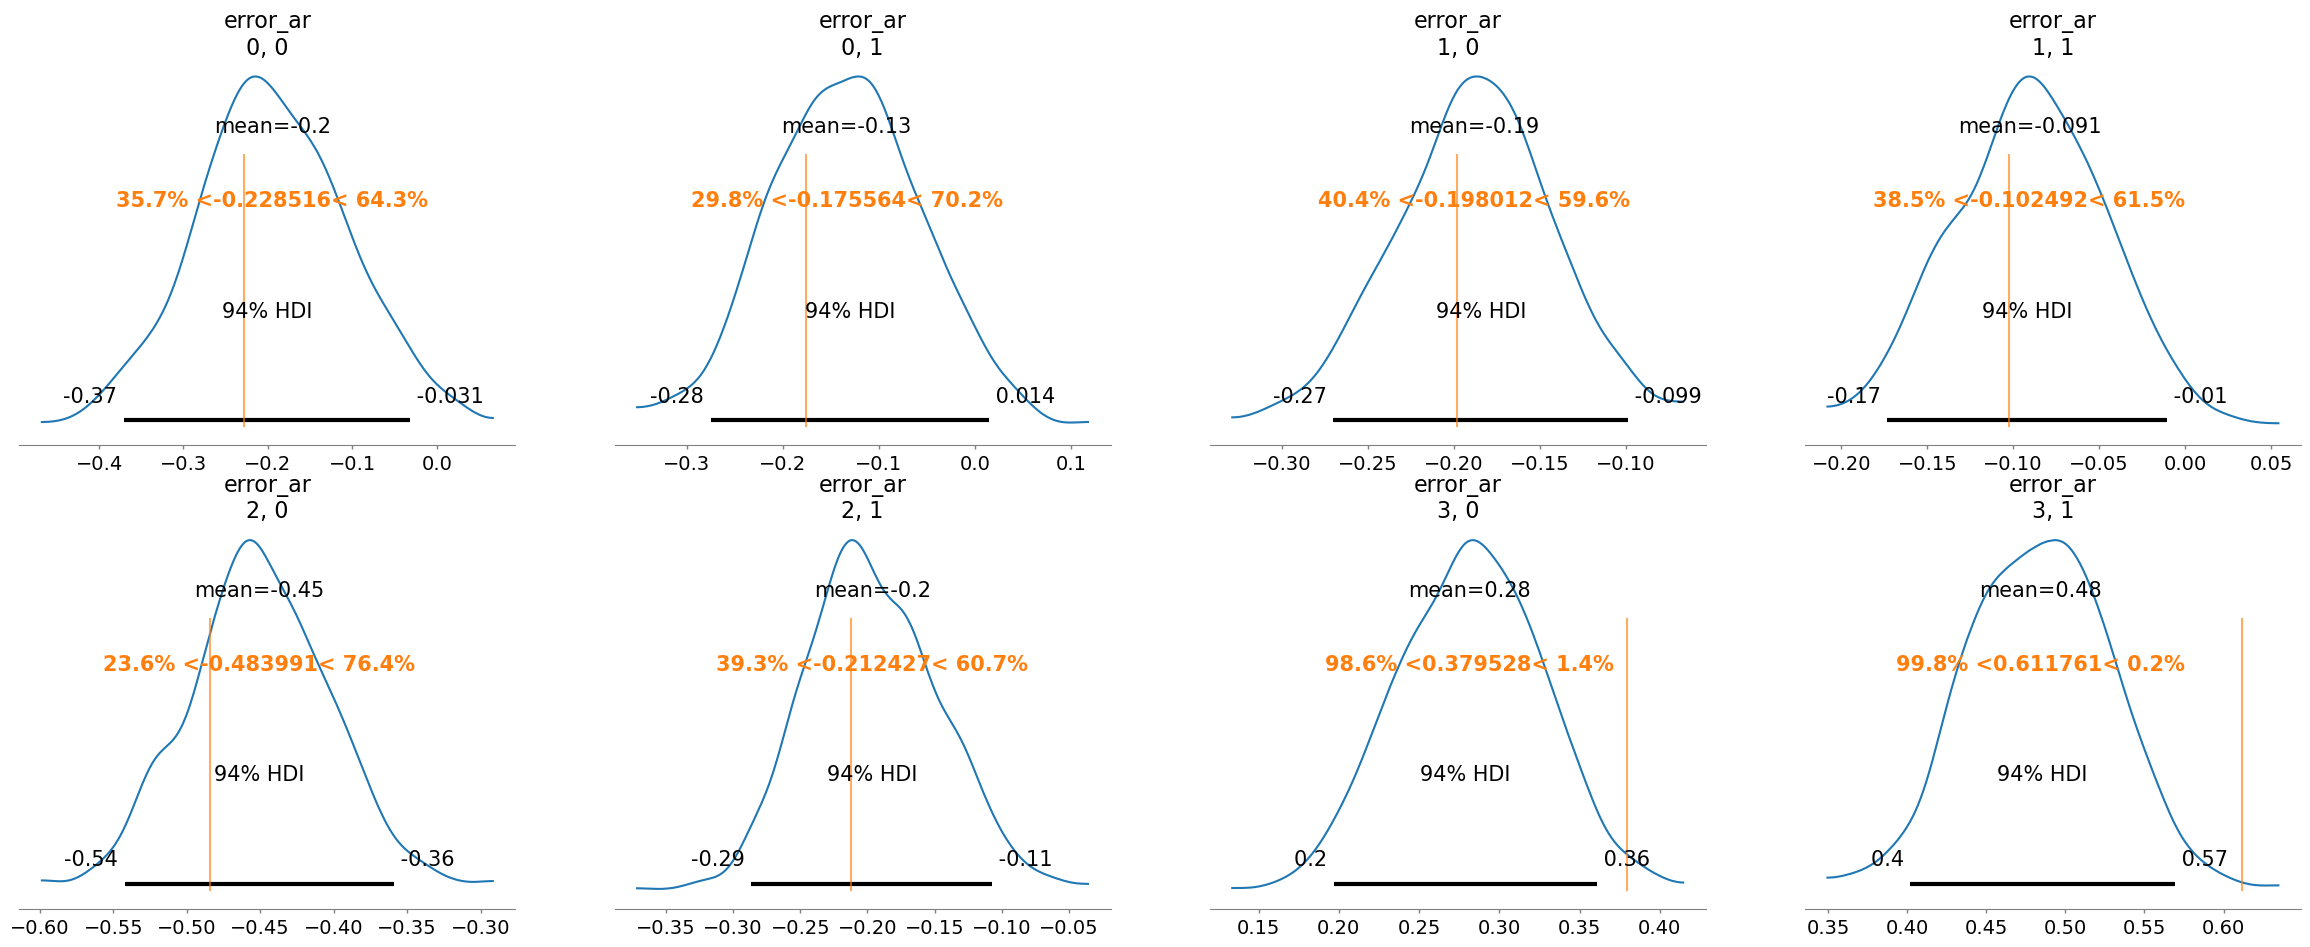

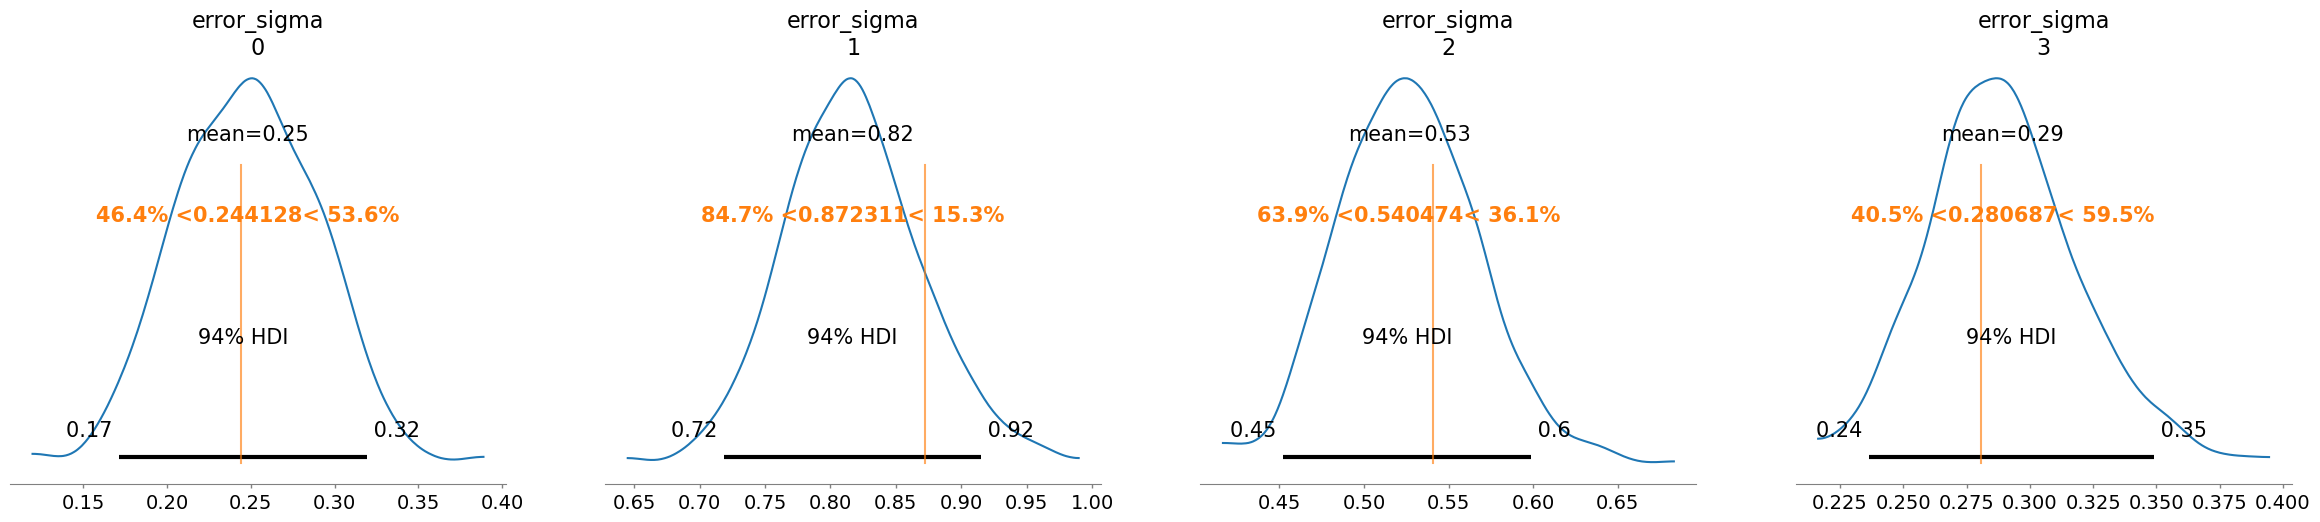

In [50]:
# Define ref values in an organized way
ref_vals = {
    "factor_ar": [params['L1.f1.f1'], params['L2.f1.f1']],
    "factor_loadings": [
        params['loading.f1.std_indprod'],
        params['loading.f1.std_income'],
        params['loading.f1.std_sales'],
        params['loading.f1.std_emp']
    ],
    "error_ar": [
        params['L1.e(std_indprod).e(std_indprod)'], params['L2.e(std_indprod).e(std_indprod)'],
        params['L1.e(std_income).e(std_income)'], params['L2.e(std_income).e(std_income)'],
        params['L1.e(std_sales).e(std_sales)'], params['L2.e(std_sales).e(std_sales)'],
        params['L1.e(std_emp).e(std_emp)'], params['L2.e(std_emp).e(std_emp)']
    ],
    "error_sigma": [
        params['sigma2.std_indprod'],
        params['sigma2.std_income'],
        params['sigma2.std_sales'],
        params['sigma2.std_emp']
    ]

}

# Helper function to plot
def plot_param_posteriors(var_name, ref_val_list):
    az.plot_posterior(
        idata_dfm_py,
        var_names=[var_name],
        ref_val=ref_val_list
    )

# Plot all
for var, ref in ref_vals.items():
    plot_param_posteriors(var, ref)


In [ ]:
with pm.Model() as index_mod:
    dfm._build_dummy_graph()
    dfm._insert_random_variables()
    x0, P0, C, D, T, Z, R, H, Q = matrices = dfm.unpack_statespace()

    dfm.build_statespace_graph(data=endog, mode="JAX", save_kalman_filter_outputs_in_idata=True)
    predicted_covariance = index_mod["predicted_covariances"]
    filtered_state = index_mod["filtered_states"]

    def step(P, Z, T, H):
        PZT = pt.dot(P, Z.T)
        F = Z.dot(PZT) + H + pt.eye(H.shape[0]) * 1e-6

        K = pt.linalg.solve(F, PZT.T, assume_a="pos", check_finite=False).T
        return K

    ss_kalman_gain, updates = pytensor.scan(step, non_sequences=[Z, T, H], 
                                           sequences=[predicted_covariance])
    
    ss_kalman_gain = ss_kalman_gain[-1] # Get the last Kalman gain (steady state)

    k_states = T.shape[0]
    W1 = pt.linalg.inv(
        pt.eye(k_states)
        - pt.dot(pt.eye(k_states) - pt.dot(ss_kalman_gain, Z), T)
    ).dot(ss_kalman_gain)[0]

    # Compute the factor mean vector
    factor_mean = pt.dot(W1, data.loc[start:, "dln_indprod":"dln_emp"].mean())

    state_0 = filtered_state[..., 0]

    # Normalization
    normalizer = np.std(usphci.diff()[1:]) / pt.std(state_0)
    state_0_scaled = state_0 * normalizer

    # Initial value (scalar)
    initial_value = usphci.iloc[0] * factor_mean / dusphci.mean()

    # Increments: each increment is state[t] + factor_mean (broadcasted)
    increments = state_0_scaled + factor_mean  # shape: (T,)

    # Cumulative sum of increments
    cumsum_increments = pt.cumsum(increments)
    coincident_index = pt.concatenate([[initial_value], initial_value + cumsum_increments])

    # Normalize to match USPHCI base year (e.g., July 1992)
    ref_idx = list(data.index).index(pd.Timestamp("1992-07-01"))
    base_value = usphci.loc["1992-07-01"]
    normalization_factor = base_value / coincident_index[ref_idx]
    coincident_index = coincident_index * normalization_factor

    pm.Deterministic("factor_mean", factor_mean)

    factor_mean_idata_dfm_py=pm.sample_posterior_predictive(idata_dfm_py, var_names=["factor_mean"])
    filtered_state_idata_dfm_py = pm.sample_posterior_predictive(idata_dfm_py, var_names=["filtered_states"])

    pm.Deterministic("coincident_index", coincident_index)
    coincident_index_idata_dfm_py = pm.sample_posterior_predictive(idata_dfm_py, var_names=["coincident_index"])


Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

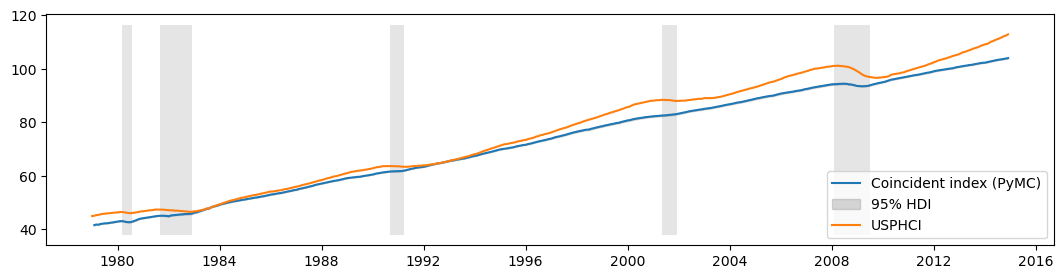

In [ ]:
fig, ax = plt.subplots(figsize=(13, 3))

# Compute the index
coincident_index_pymc_samples_dfm_py = coincident_index_idata_dfm_py.posterior_predictive["coincident_index"].values
coincident_index_pymc_dfm_py = coincident_index_pymc_samples_dfm_py.mean(axis=(0, 1))


hdi_index_dfm_py = az.hdi(coincident_index_pymc_samples_dfm_py, hdi_prob=0.95)  
lower_index_dfm_py, upper_index_dfm_py = hdi_index_dfm_py[..., 0], hdi_index_dfm_py[..., 1]    

# Plot the factor
dates = endog.index._mpl_repr()
ax.plot(dates, coincident_index_pymc_dfm_py[1:], label="Coincident index (PyMC)")
ax.fill_between(dates, lower_index_dfm_py[1:], upper_index_dfm_py[1:], color='gray', alpha=0.3, label="95% HDI")
ax.plot(usphci.index._mpl_repr(), usphci, label="USPHCI")
ax.legend(loc="lower right")

# Retrieve and also plot the NBER recession indicators
ylim = ax.get_ylim()
ax.fill_between(
    dates[:-3], ylim[0], ylim[1], rec.values[:-4, 0], facecolor="k", alpha=0.1
);

In [ ]:
# Extract posterior predictive samples
state_samples_dfm_py = filtered_state_idata_dfm_py.posterior_predictive["filtered_states"].values  # shape: (2, 500, 10, 431)

# Select the first state (index 0)
state_0_samples_dfm_py = state_samples_dfm_py[:, :, :, 0]  # shape: (1, 1000, 431)

# Average over chains and draws to get posterior mean for each time point
state_0_mean_dfm_py = state_0_samples_dfm_py.mean(axis=(0, 1))  # shape: (431,)

# Get the time index from your observed data for x-axis
dates = filtered_state_idata_dfm_py.observed_data.time.values  # array of datetime64


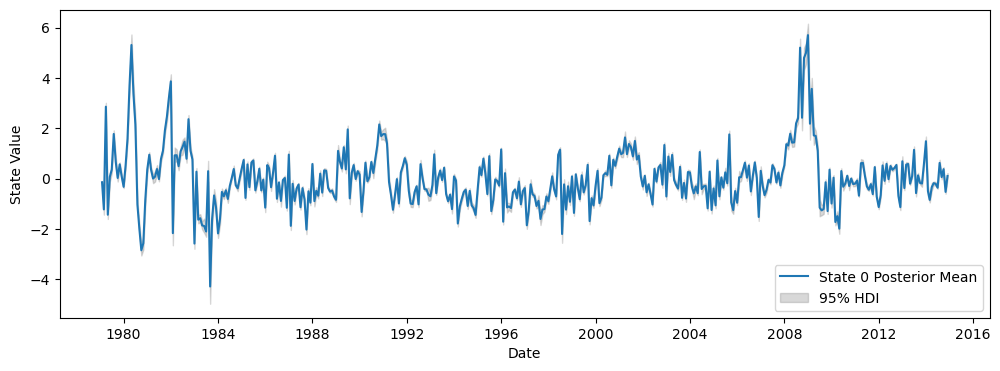

In [ ]:
hdi_state_dfm_py = az.hdi(state_0_samples_dfm_py, hdi_prob=0.95)  
lower_state_dfm_py, upper_state_dfm_py = hdi_state_dfm_py[..., 0], hdi_state_dfm_py[..., 1]    

# Plot
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(dates, state_0_mean_dfm_py, label="State 0 Posterior Mean")
ax.fill_between(dates, lower_state_dfm_py, upper_state_dfm_py, color='gray', alpha=0.3, label="95% HDI")
ax.set_xlabel("Date")
ax.set_ylabel("State Value")
ax.legend()
plt.show()

## Comparison of PyMC (Dummy and using DFM.py) and Stats

In [ ]:
res.params

loading.f1.std_indprod             -0.695363
loading.f1.std_income              -0.250427
loading.f1.std_sales               -0.437283
loading.f1.std_emp                 -0.425481
sigma2.std_indprod                  0.244128
sigma2.std_income                   0.872311
sigma2.std_sales                    0.540474
sigma2.std_emp                      0.280687
L1.f1.f1                            0.302372
L2.f1.f1                            0.367105
L1.e(std_indprod).e(std_indprod)   -0.228516
L2.e(std_indprod).e(std_indprod)   -0.175564
L1.e(std_income).e(std_income)     -0.198012
L2.e(std_income).e(std_income)     -0.102492
L1.e(std_sales).e(std_sales)       -0.483991
L2.e(std_sales).e(std_sales)       -0.212427
L1.e(std_emp).e(std_emp)            0.379528
L2.e(std_emp).e(std_emp)            0.611761
dtype: float64

In [ ]:
az.summary(idata_dfm_py, var_names=var_names_list_dfm_py)

arviz - WARNING - Shape validation failed: input_shape: (1, 500), minimum_shape: (chains=2, draws=4)


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
"factor_loadings[0, 0]",-0.710,0.040,-0.782,-0.637,0.002,0.001,399.0,497.0,NaN
"factor_loadings[1, 0]",-0.255,0.034,-0.314,-0.186,0.001,0.002,965.0,477.0,NaN
"factor_loadings[2, 0]",-0.446,0.031,-0.506,-0.386,0.001,0.002,519.0,344.0,NaN
"factor_loadings[3, 0]",-0.416,0.041,-0.487,-0.340,0.002,0.002,545.0,389.0,NaN
"factor_ar[0, 0]",0.304,0.051,0.218,0.398,0.002,0.002,508.0,330.0,NaN
"factor_ar[0, 1]",0.369,0.049,0.274,0.456,0.002,0.002,564.0,383.0,NaN
"error_ar[0, 0]",-0.234,0.075,-0.371,-0.104,0.002,0.003,1242.0,385.0,NaN
"error_ar[0, 1]",-0.178,0.067,-0.301,-0.058,0.002,0.003,1312.0,463.0,NaN
"error_ar[1, 0]",-0.197,0.042,-0.265,-0.107,0.001,0.002,1349.0,370.0,NaN
"error_ar[1, 1]",-0.099,0.046,-0.184,-0.016,0.002,0.002,869.0,423.0,NaN


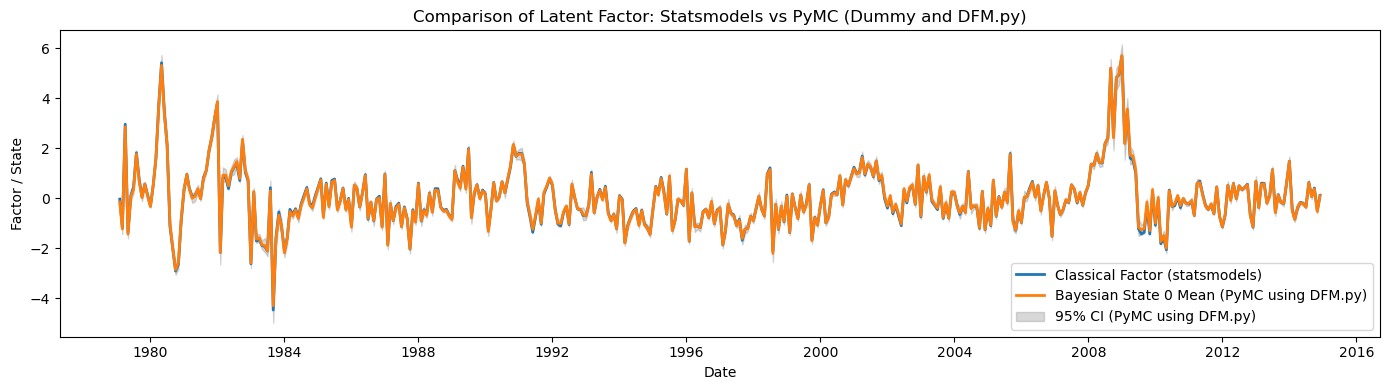

In [ ]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(dates, res.factors.filtered[0], label="Classical Factor (statsmodels)", linewidth=2)
ax.plot(dates, state_0_mean_dfm_py, label="Bayesian State 0 Mean (PyMC using DFM.py)", linewidth=2)
ax.fill_between(dates, lower_state_dfm_py, upper_state_dfm_py, color='gray', alpha=0.3, label="95% CI (PyMC using DFM.py)")
ax.legend()
ax.set_title("Comparison of Latent Factor: Statsmodels vs PyMC (Dummy and DFM.py)")
ax.set_xlabel("Date")
ax.set_ylabel("Factor / State")
plt.tight_layout()
plt.show()

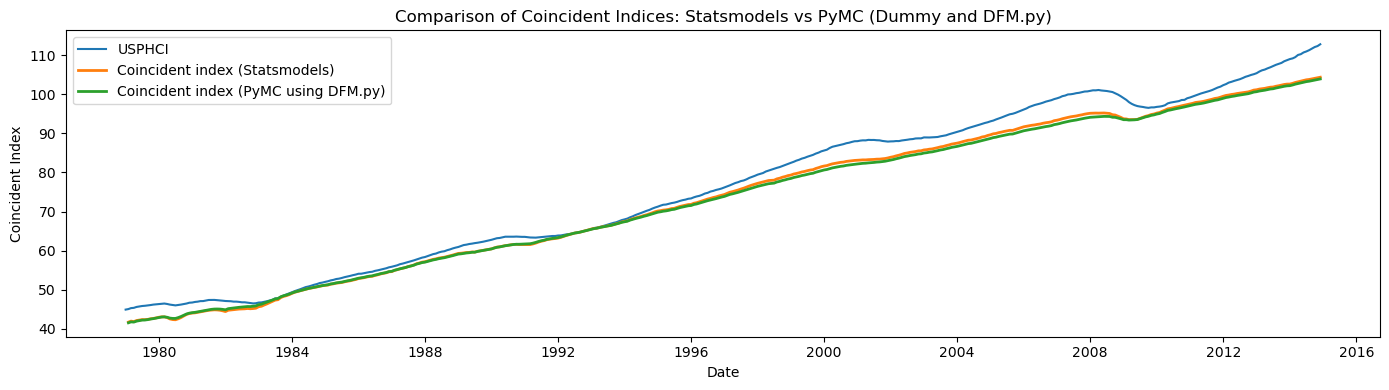

In [ ]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(usphci.index._mpl_repr(), usphci, label="USPHCI")
ax.plot(dates, coincident_index_res, label="Coincident index (Statsmodels)", linewidth=2)
ax.plot(dates, coincident_index_pymc_dfm_py[1:], label="Coincident index (PyMC using DFM.py)", linewidth=2)
ax.legend()
ax.set_title("Comparison of Coincident Indices: Statsmodels vs PyMC (Dummy and DFM.py)")
ax.set_xlabel("Date")
ax.set_ylabel("Coincident Index")
plt.tight_layout()
plt.show()

### PyMC using DFM.py

In [51]:
# Initialize the model
dfm = BayesianDynamicFactor(
    k_endog=4,
    k_factors=1,
    factor_order=2,
    error_order=2,
    error_var=False,
    error_cov_type="diagonal",
    measurement_error=False,
    verbose=True,
)

                                     Model Requirements                                     
                                                                                            
  Variable          Shape      Constraints                                      Dimensions  
 ────────────────────────────────────────────────────────────────────────────────────────── 
  x0                (10,)                                                       ('state',)  
  P0                (10, 10)   Positive Semi-definite               ('state', 'state_aux')  
  factor_loadings   (4, 1)                                    ('observed_state', 'factor')  
  factor_ar         (1, 2)                                            ('factor', 'lag_ar')  
  error_ar          (4, 2)                              ('observed_state', 'error_lag_ar')  
  error_sigma       (4,)       Positive                                ('observed_state',)  
                                                                                            
  These parameters should be assigned priors inside a PyMC model block before calling the   
                               build_statespace_graph method.                               

In [60]:
params = res.params.to_dict()

with pm.Model() as pymc_mod:

    # Initial state
    x0 = pm.Deterministic("x0", pt.zeros(10))
    P0 = pm.Deterministic("P0", pt.eye(10))

    # Factor loadings vector
    factor_loadings = pm.HalfNormal("factor_loadings", sigma=0.2, shape=(4,1))

    # AR(2) coefficients for factor f_t
    factor_ar = pm.Normal("factor_ar", mu=0.0, sigma=0.2, shape=(1,2))

    # AR(2) coefficients for idiosyncratic components as matrix error_ar_mu: shape (4, 2)
    error_ar = pm.Normal("error_ar", mu=0.0, sigma=0.2, shape=(4, 2))

    # Standard deviations for idiosyncratic shocks
    error_sigma = pm.HalfNormal("error_sigma", sigma=0.2, shape=(4))

    # Build symbolic graph
    dfm.build_statespace_graph(data=endog, mode="JAX")

In [61]:
print_model_ssm(dfm, "draw")

name                __repr__                                          shape     value               
initial_state       initial_state                                     (10,)     [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
----------------------------------------------------------------------------------------------------
initial_state_cov   initial_state_cov                                 (10, 10)  [[1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
                                                                                 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
                                                                                 [0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
                                                                                 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
                                                                                 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
                                                                                 [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
        

In [62]:
with pymc_mod:
    idata = pm.sample(
        draws=500,
        chains=2,
        nuts_sampler="nutpie",
        nuts_sampler_kwargs={"backend": "jax", "gradient_backend": "jax"},
        random_seed=1,
    )

Progress,Draws,Divergences,Step Size,Gradients/Draw
,1500,0,0.62,7
,1500,0,0.62,7


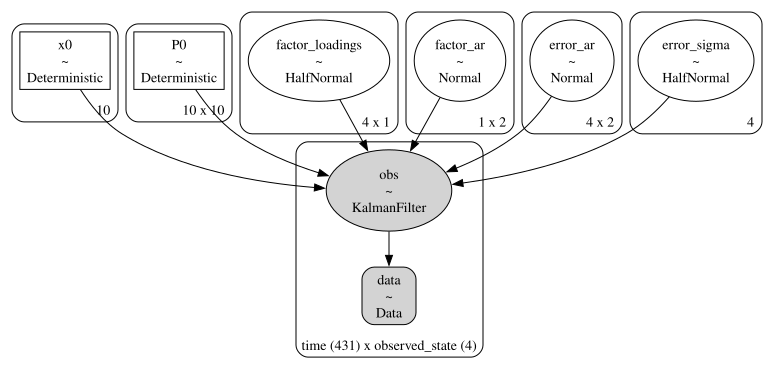

In [63]:
pymc_mod.to_graphviz()

In [64]:
idata.to_netcdf("Results/NutpieNoPrior4.nc")

'Results/NutpieNoPrior4.nc'

In [65]:
idata_dfm_py = az.from_netcdf("Results/NutpieNoPrior4.nc")

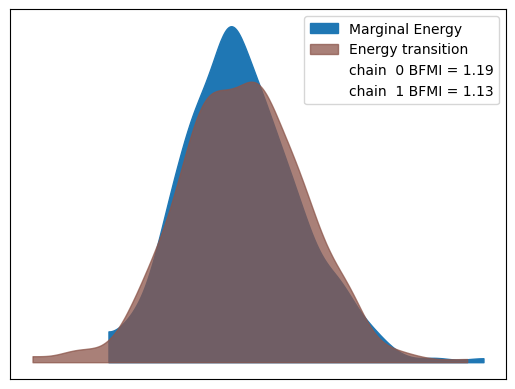

In [66]:
az.plot_energy(idata_dfm_py);

In [67]:
var_names_list_dfm_py = [name for name in dfm.param_names if name not in {"x0", "P0"}]

In [68]:
az.summary(idata_dfm_py, var_names=var_names_list_dfm_py)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
"factor_loadings[0, 0]",0.677,0.042,0.599,0.756,0.002,0.001,641.0,680.0,1.00
"factor_loadings[1, 0]",0.242,0.033,0.180,0.302,0.001,0.001,1814.0,818.0,1.00
"factor_loadings[2, 0]",0.425,0.030,0.370,0.487,0.001,0.001,716.0,847.0,1.00
"factor_loadings[3, 0]",0.397,0.040,0.323,0.469,0.001,0.001,969.0,799.0,1.00
"factor_ar[0, 0]",0.309,0.059,0.195,0.416,0.002,0.001,807.0,772.0,1.00
"factor_ar[0, 1]",0.357,0.058,0.254,0.462,0.002,0.001,1095.0,985.0,1.00
"error_ar[0, 0]",-0.190,0.086,-0.349,-0.017,0.002,0.003,1377.0,949.0,1.00
"error_ar[0, 1]",-0.134,0.083,-0.279,0.030,0.003,0.002,1036.0,767.0,1.00
"error_ar[1, 0]",-0.184,0.046,-0.270,-0.107,0.001,0.001,1899.0,736.0,1.01
"error_ar[1, 1]",-0.090,0.047,-0.172,-0.001,0.001,0.002,2208.0,688.0,1.00


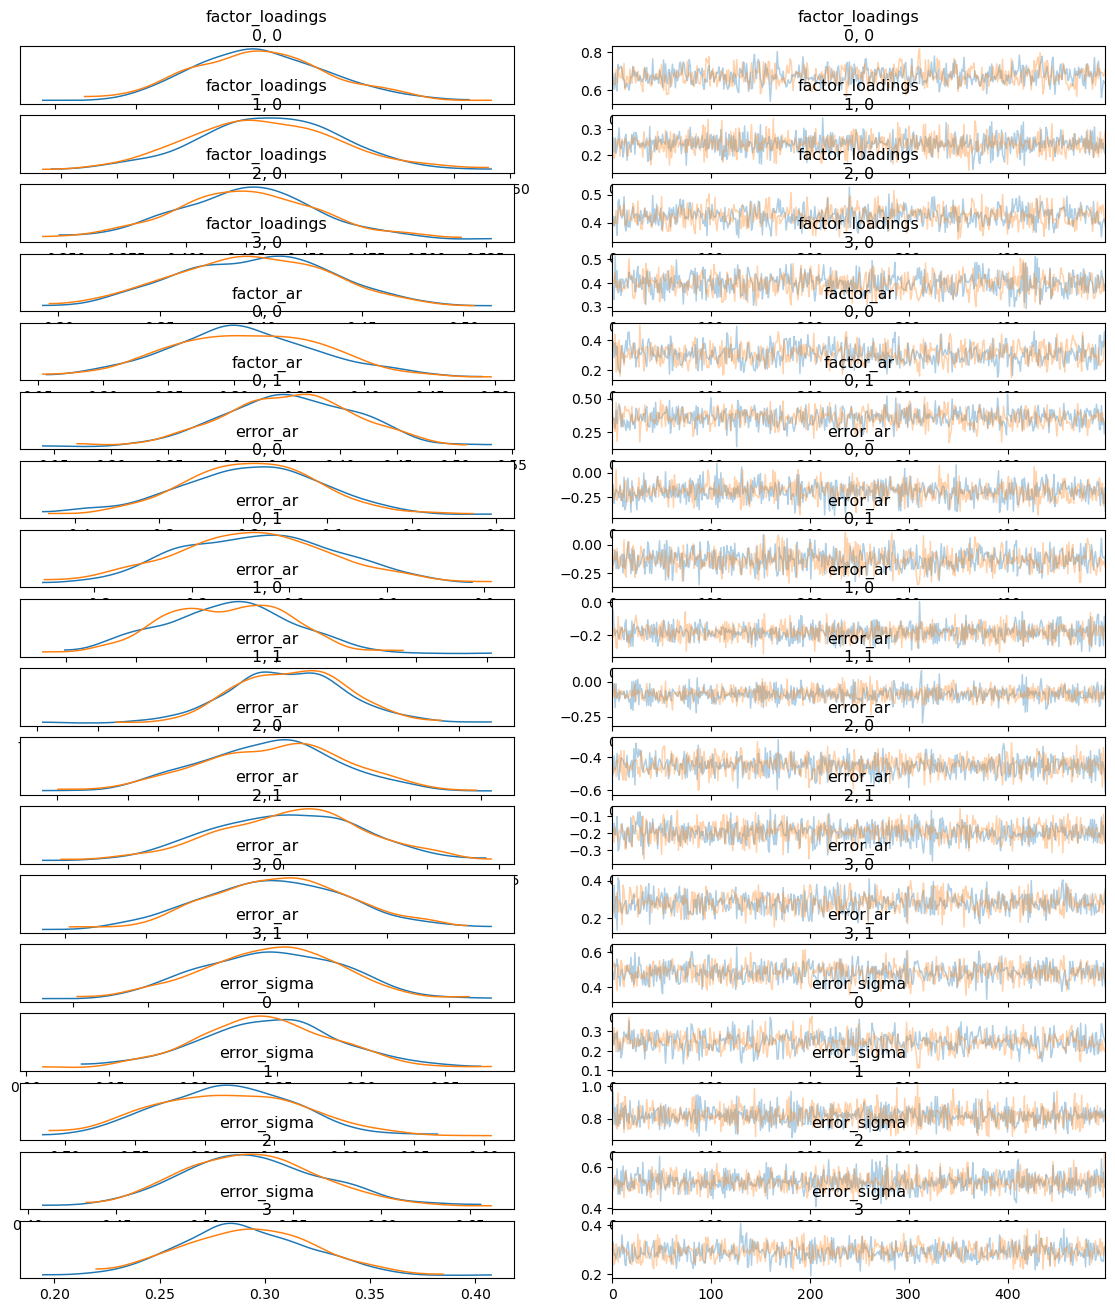

In [69]:
az.plot_trace(
    idata_dfm_py,
    var_names=var_names_list_dfm_py,
    figsize=(14, 16),
    compact=False
);

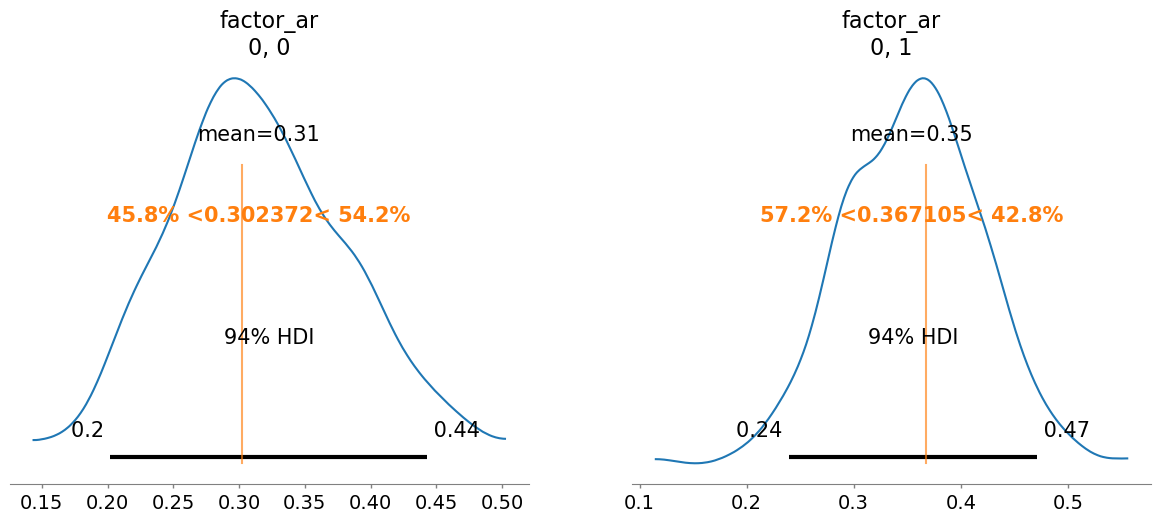

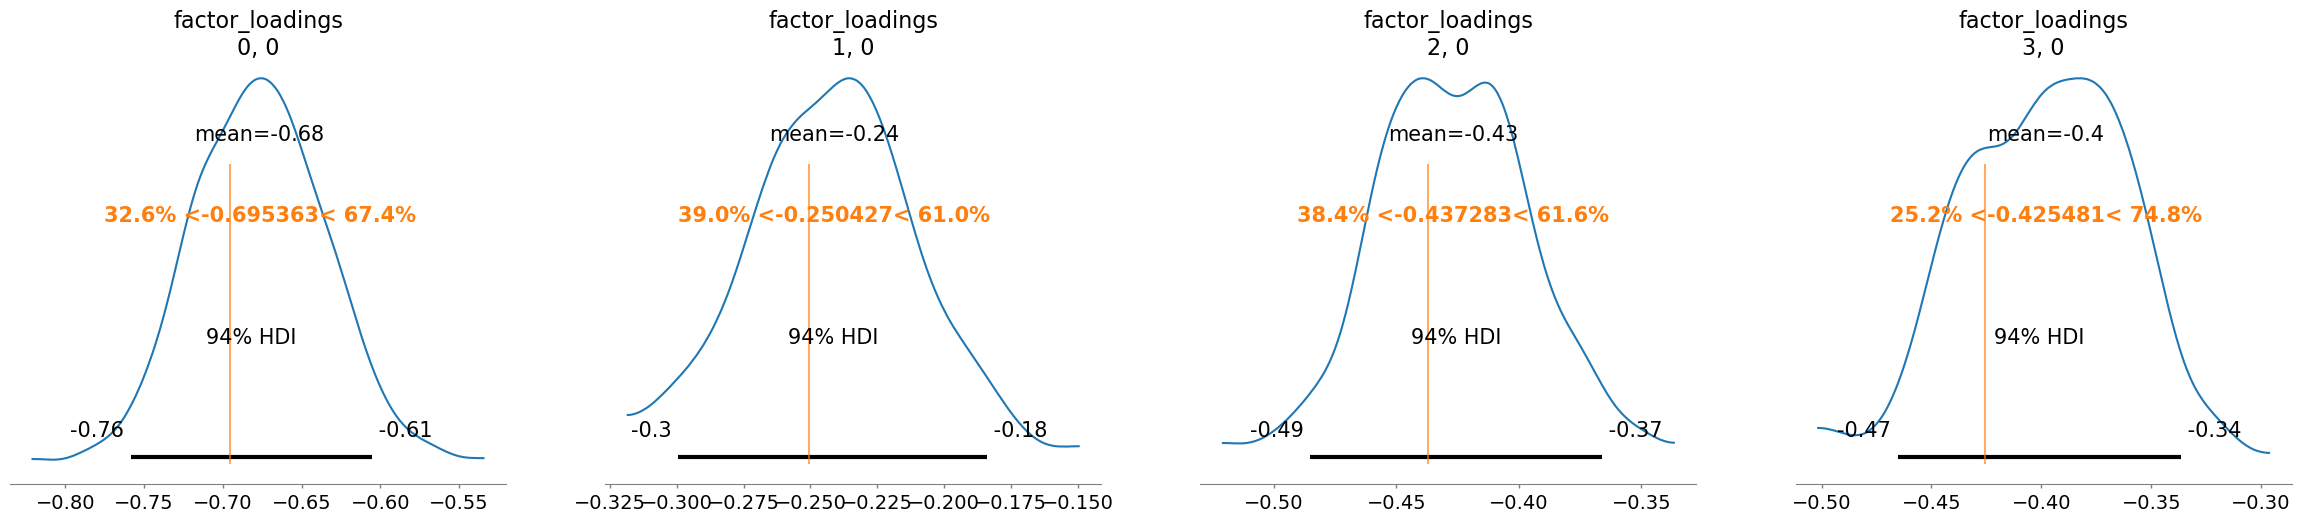

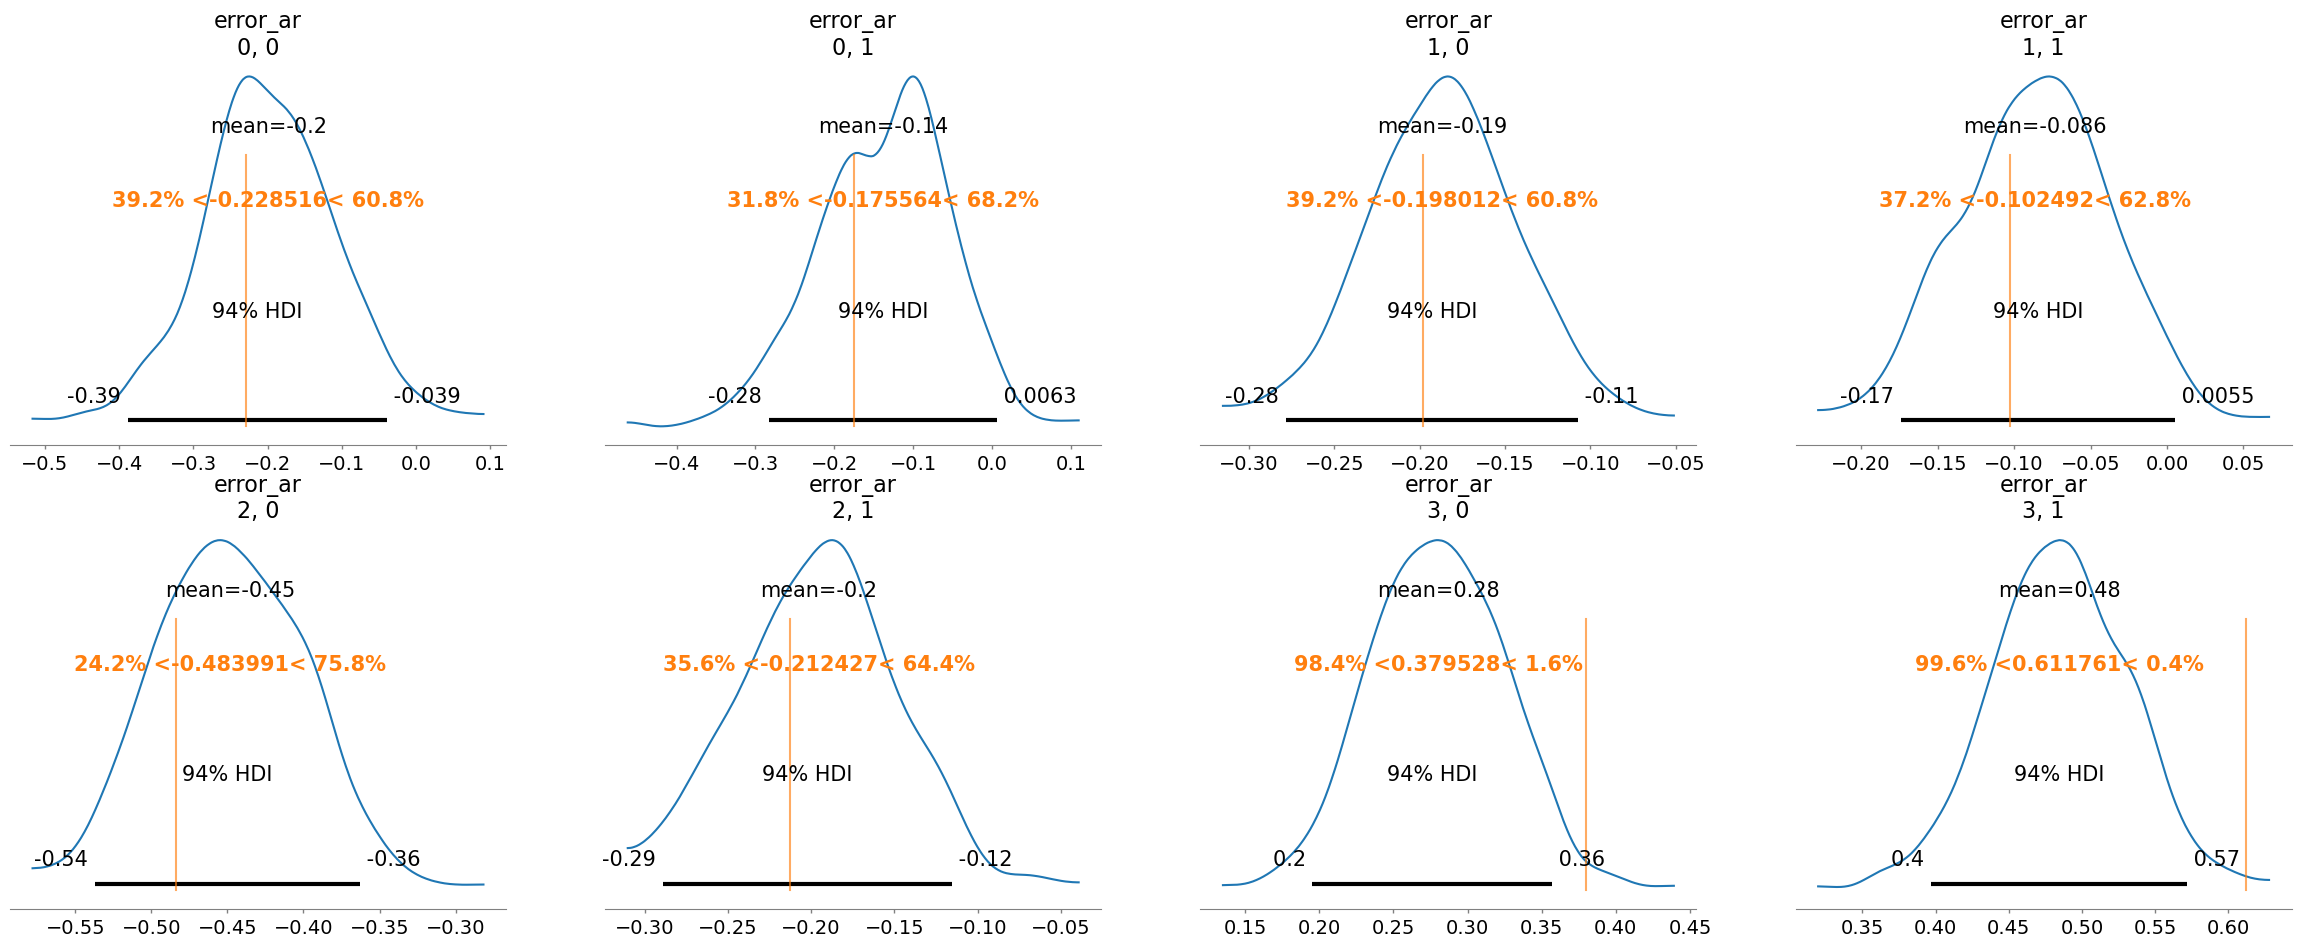

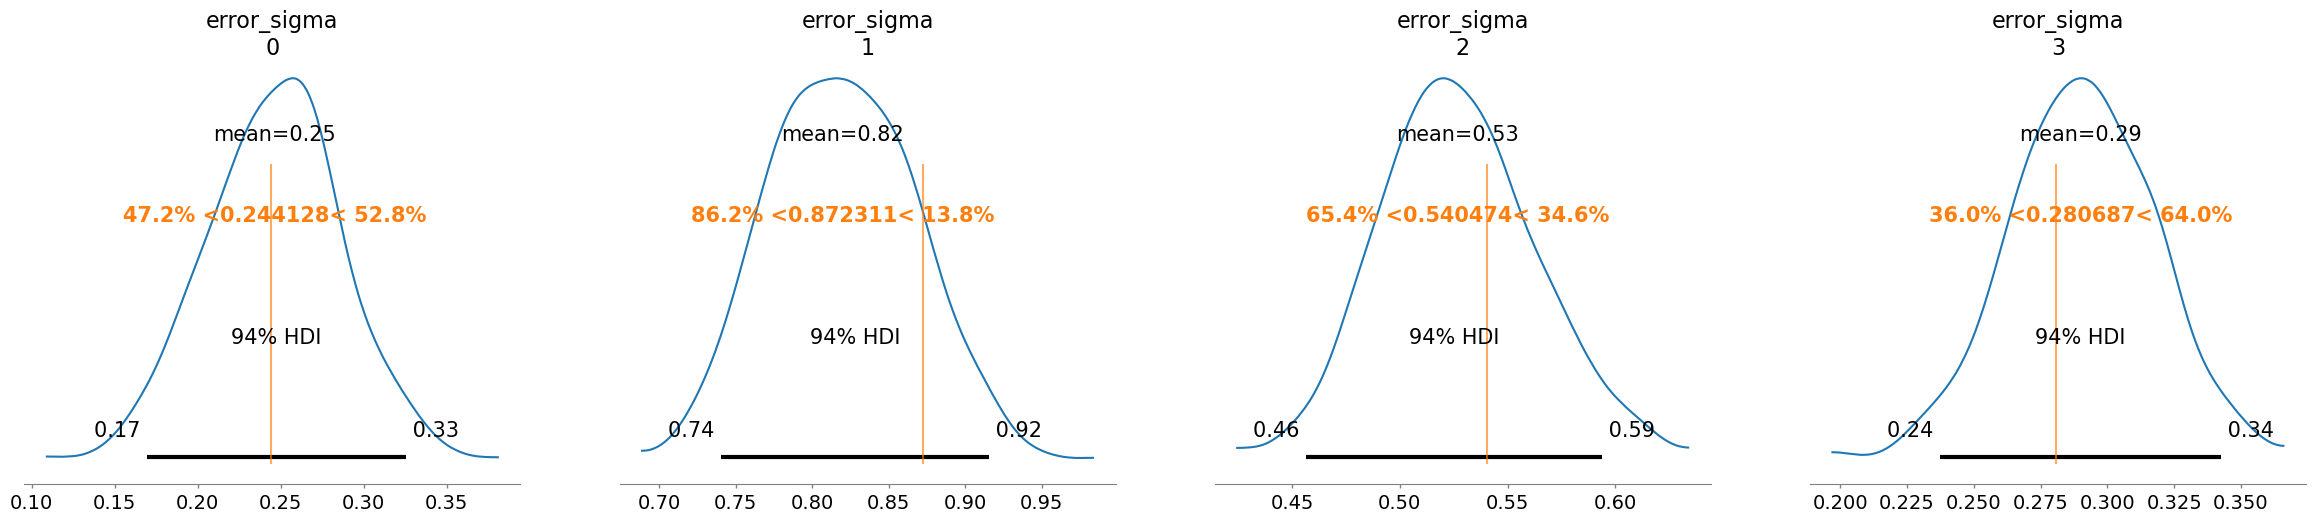

In [ ]:
# Define ref values in an organized way
ref_vals = {
    "factor_ar": [params['L1.f1.f1'], params['L2.f1.f1']],
    "factor_loadings": [
        params['loading.f1.std_indprod'],
        params['loading.f1.std_income'],
        params['loading.f1.std_sales'],
        params['loading.f1.std_emp']
    ],
    "error_ar": [
        params['L1.e(std_indprod).e(std_indprod)'], params['L2.e(std_indprod).e(std_indprod)'],
        params['L1.e(std_income).e(std_income)'], params['L2.e(std_income).e(std_income)'],
        params['L1.e(std_sales).e(std_sales)'], params['L2.e(std_sales).e(std_sales)'],
        params['L1.e(std_emp).e(std_emp)'], params['L2.e(std_emp).e(std_emp)']
    ],
    "error_sigma": [
        params['sigma2.std_indprod'],
        params['sigma2.std_income'],
        params['sigma2.std_sales'],
        params['sigma2.std_emp']
    ]

}

# Helper function to plot
def plot_param_posteriors(var_name, ref_val_list):
    az.plot_posterior(
        idata_dfm_py,
        var_names=[var_name],
        ref_val=ref_val_list
    )

# Plot all
for var, ref in ref_vals.items():
    plot_param_posteriors(var, ref)


In [70]:
with pm.Model() as index_mod:
    dfm._build_dummy_graph()
    dfm._insert_random_variables()
    x0, P0, C, D, T, Z, R, H, Q = matrices = dfm.unpack_statespace()

    dfm.build_statespace_graph(data=endog, mode="JAX", save_kalman_filter_outputs_in_idata=True)
    predicted_covariance = index_mod["predicted_covariances"]
    filtered_state = index_mod["filtered_states"]

    def step(P, Z, T, H):
        PZT = pt.dot(P, Z.T)
        F = Z.dot(PZT) + H + pt.eye(H.shape[0]) * 1e-6

        # K = pt.linalg.solve(F, pt.dot(T, PZT).T, assume_a="pos", check_finite=False).T   
        K = pt.linalg.solve(F, PZT.T, assume_a="pos", check_finite=False).T
        return K

    ss_kalman_gain, updates = pytensor.scan(step, non_sequences=[Z, T, H], 
                                           sequences=[predicted_covariance])
    
    ss_kalman_gain = ss_kalman_gain[-1] # Get the last Kalman gain (steady state)

    k_states = T.shape[0]
    W1 = pt.linalg.inv(
        pt.eye(k_states)
        - pt.dot(pt.eye(k_states) - pt.dot(ss_kalman_gain, Z), T)
    ).dot(ss_kalman_gain)[0]

    # Compute the factor mean vector
    factor_mean = pt.dot(W1, data.loc[start:, "dln_indprod":"dln_emp"].mean())

    state_0 = filtered_state[..., 0]

    # Normalization
    normalizer = np.std(usphci.diff()[1:]) / pt.std(state_0)
    state_0_scaled = state_0 * normalizer

    # Initial value (scalar)
    initial_value = usphci.iloc[0] * factor_mean / dusphci.mean()

    # Increments: each increment is state[t] + factor_mean (broadcasted)
    increments = state_0_scaled + factor_mean  # shape: (T,)

    # Cumulative sum of increments
    cumsum_increments = pt.cumsum(increments)
    coincident_index = pt.concatenate([[initial_value], initial_value + cumsum_increments])

    # Normalize to match USPHCI base year (e.g., July 1992)
    ref_idx = list(data.index).index(pd.Timestamp("1992-07-01"))
    base_value = usphci.loc["1992-07-01"]
    normalization_factor = base_value / coincident_index[ref_idx]
    coincident_index = coincident_index * normalization_factor

    pm.Deterministic("factor_mean", factor_mean)

    factor_mean_idata_dfm_py=pm.sample_posterior_predictive(idata_dfm_py, var_names=["factor_mean"])
    filtered_state_idata_dfm_py = pm.sample_posterior_predictive(idata_dfm_py, var_names=["filtered_states"])

    pm.Deterministic("coincident_index", coincident_index)
    coincident_index_idata_dfm_py = pm.sample_posterior_predictive(idata_dfm_py, var_names=["coincident_index"])


Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

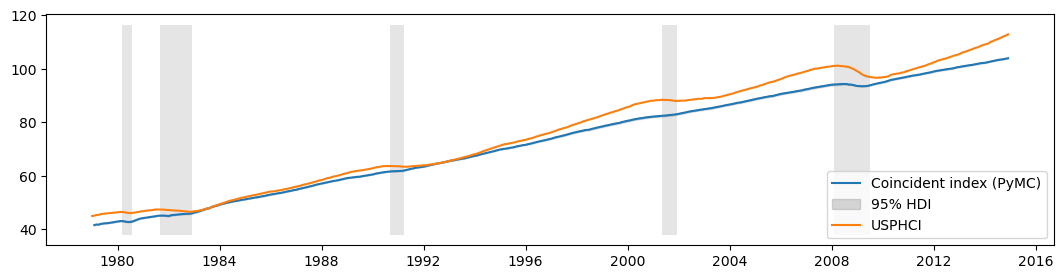

In [74]:
fig, ax = plt.subplots(figsize=(13, 3))

# Compute the index
coincident_index_pymc_samples_dfm_py = coincident_index_idata_dfm_py.posterior_predictive["coincident_index"].values
coincident_index_pymc_dfm_py = coincident_index_pymc_samples_dfm_py.mean(axis=(0, 1))


hdi_index_dfm_py = az.hdi(coincident_index_pymc_samples_dfm_py, hdi_prob=0.95)  
lower_index_dfm_py, upper_index_dfm_py = hdi_index_dfm_py[..., 0], hdi_index_dfm_py[..., 1]    

# Plot the factor
dates = endog.index._mpl_repr()
ax.plot(dates, coincident_index_pymc_dfm_py[1:], label="Coincident index (PyMC)")
ax.fill_between(dates, lower_index_dfm_py[1:], upper_index_dfm_py[1:], color='gray', alpha=0.3, label="95% HDI")
ax.plot(usphci.index._mpl_repr(), usphci, label="USPHCI")
ax.legend(loc="lower right")

# Retrieve and also plot the NBER recession indicators
ylim = ax.get_ylim()
ax.fill_between(
    dates[:-3], ylim[0], ylim[1], rec.values[:-4, 0], facecolor="k", alpha=0.1
);

In [75]:
# Extract posterior predictive samples
state_samples_dfm_py = filtered_state_idata_dfm_py.posterior_predictive["filtered_states"].values  # shape: (2, 500, 10, 431)

# Select the first state (index 0)
state_0_samples_dfm_py = state_samples_dfm_py[:, :, :, 0]  # shape: (1, 1000, 431)

# Average over chains and draws to get posterior mean for each time point
state_0_mean_dfm_py = state_0_samples_dfm_py.mean(axis=(0, 1))  # shape: (431,)

# Get the time index from your observed data for x-axis
dates = filtered_state_idata_dfm_py.observed_data.time.values  # array of datetime64


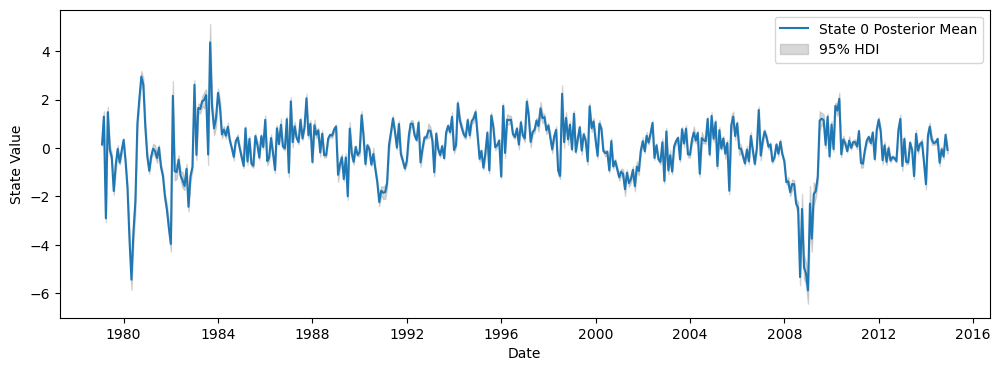

In [76]:
hdi_state_dfm_py = az.hdi(state_0_samples_dfm_py, hdi_prob=0.95)  
lower_state_dfm_py, upper_state_dfm_py = hdi_state_dfm_py[..., 0], hdi_state_dfm_py[..., 1]    

# Plot
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(dates, state_0_mean_dfm_py, label="State 0 Posterior Mean")
ax.fill_between(dates, lower_state_dfm_py, upper_state_dfm_py, color='gray', alpha=0.3, label="95% HDI")
ax.set_xlabel("Date")
ax.set_ylabel("State Value")
ax.legend()
plt.show()

## Comparison of PyMC (Dummy and using DFM.py) and Stats

In [77]:
res.params

loading.f1.std_indprod             -0.695363
loading.f1.std_income              -0.250427
loading.f1.std_sales               -0.437283
loading.f1.std_emp                 -0.425481
sigma2.std_indprod                  0.244128
sigma2.std_income                   0.872311
sigma2.std_sales                    0.540474
sigma2.std_emp                      0.280687
L1.f1.f1                            0.302372
L2.f1.f1                            0.367105
L1.e(std_indprod).e(std_indprod)   -0.228516
L2.e(std_indprod).e(std_indprod)   -0.175564
L1.e(std_income).e(std_income)     -0.198012
L2.e(std_income).e(std_income)     -0.102492
L1.e(std_sales).e(std_sales)       -0.483991
L2.e(std_sales).e(std_sales)       -0.212427
L1.e(std_emp).e(std_emp)            0.379528
L2.e(std_emp).e(std_emp)            0.611761
dtype: float64

In [78]:
az.summary(idata_dfm_py, var_names=var_names_list_dfm_py)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
"factor_loadings[0, 0]",0.677,0.042,0.599,0.756,0.002,0.001,641.0,680.0,1.00
"factor_loadings[1, 0]",0.242,0.033,0.180,0.302,0.001,0.001,1814.0,818.0,1.00
"factor_loadings[2, 0]",0.425,0.030,0.370,0.487,0.001,0.001,716.0,847.0,1.00
"factor_loadings[3, 0]",0.397,0.040,0.323,0.469,0.001,0.001,969.0,799.0,1.00
"factor_ar[0, 0]",0.309,0.059,0.195,0.416,0.002,0.001,807.0,772.0,1.00
"factor_ar[0, 1]",0.357,0.058,0.254,0.462,0.002,0.001,1095.0,985.0,1.00
"error_ar[0, 0]",-0.190,0.086,-0.349,-0.017,0.002,0.003,1377.0,949.0,1.00
"error_ar[0, 1]",-0.134,0.083,-0.279,0.030,0.003,0.002,1036.0,767.0,1.00
"error_ar[1, 0]",-0.184,0.046,-0.270,-0.107,0.001,0.001,1899.0,736.0,1.01
"error_ar[1, 1]",-0.090,0.047,-0.172,-0.001,0.001,0.002,2208.0,688.0,1.00


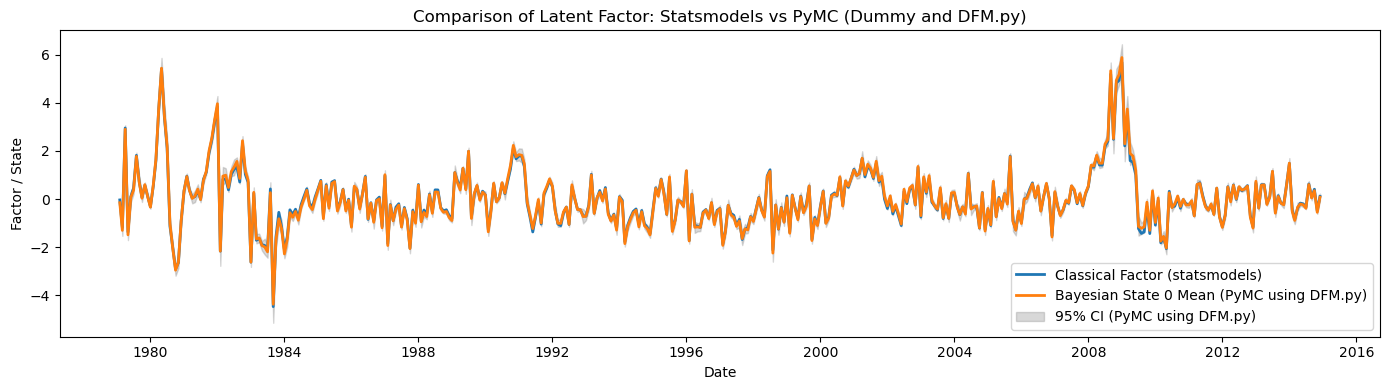

In [80]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(dates, res.factors.filtered[0], label="Classical Factor (statsmodels)", linewidth=2)
ax.plot(dates, -state_0_mean_dfm_py, label="Bayesian State 0 Mean (PyMC using DFM.py)", linewidth=2)
ax.fill_between(dates, -lower_state_dfm_py, -upper_state_dfm_py, color='gray', alpha=0.3, label="95% CI (PyMC using DFM.py)")
ax.legend()
ax.set_title("Comparison of Latent Factor: Statsmodels vs PyMC (Dummy and DFM.py)")
ax.set_xlabel("Date")
ax.set_ylabel("Factor / State")
plt.tight_layout()
plt.show()

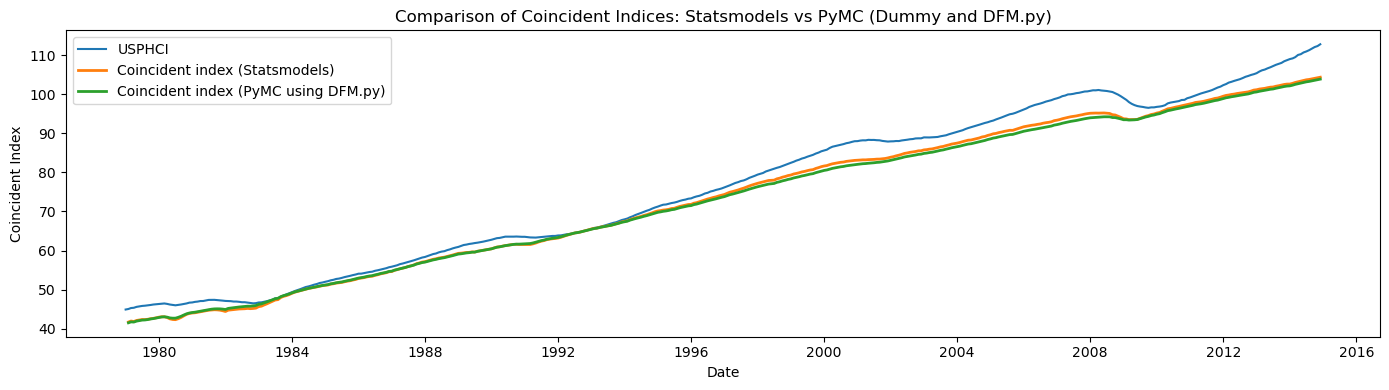

In [81]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(usphci.index._mpl_repr(), usphci, label="USPHCI")
ax.plot(dates, coincident_index_res, label="Coincident index (Statsmodels)", linewidth=2)
ax.plot(dates, coincident_index_pymc_dfm_py[1:], label="Coincident index (PyMC using DFM.py)", linewidth=2)
ax.legend()
ax.set_title("Comparison of Coincident Indices: Statsmodels vs PyMC (Dummy and DFM.py)")
ax.set_xlabel("Date")
ax.set_ylabel("Coincident Index")
plt.tight_layout()
plt.show()